 DATA EXPLORER

OOP HEART DISEASE DATA EXPLORER
Object-Oriented EDA Pipeline

STARTING EDA PIPELINE

Step 1: Loading Data...
Data loaded successfully!
Shape: 1190 rows x 12 columns

Step 2: Analyzing Data...

Column Types Identified:
   Numerical: 5 columns
   Categorical: 6 columns
   Target: target

DATASET INFORMATION

Shape: 1190 rows x 12 columns
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            0             172                0      0.0         1       0  
1            0             

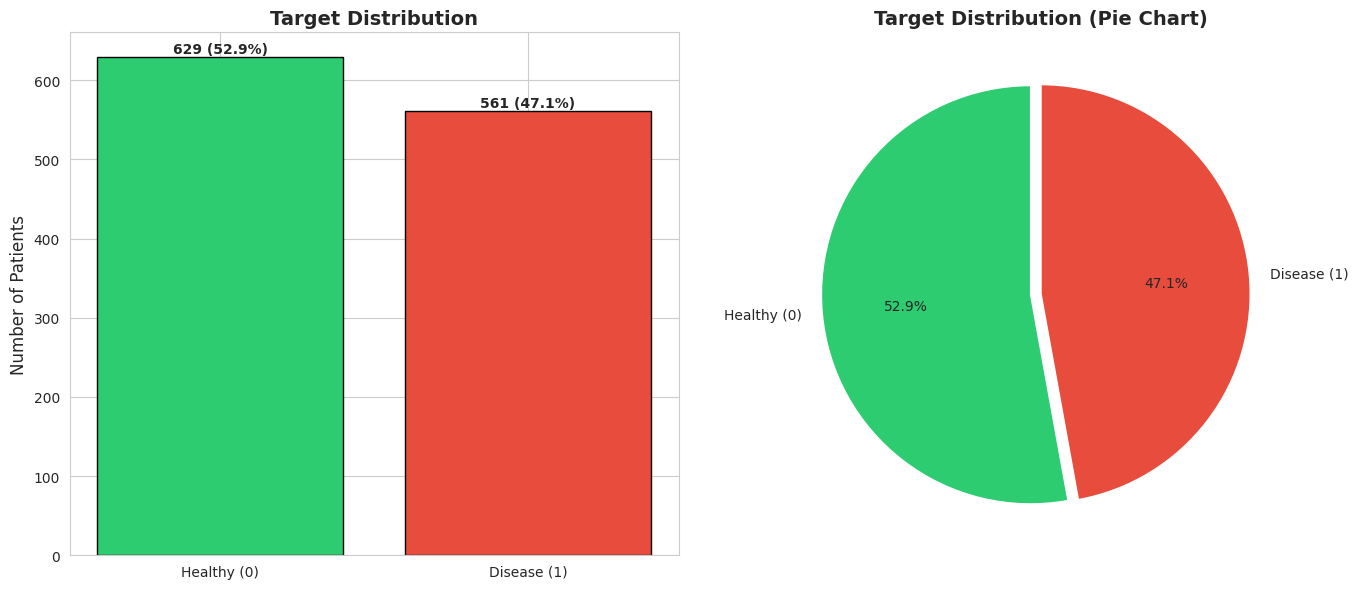

Saved: 1_Target_Distribution.png


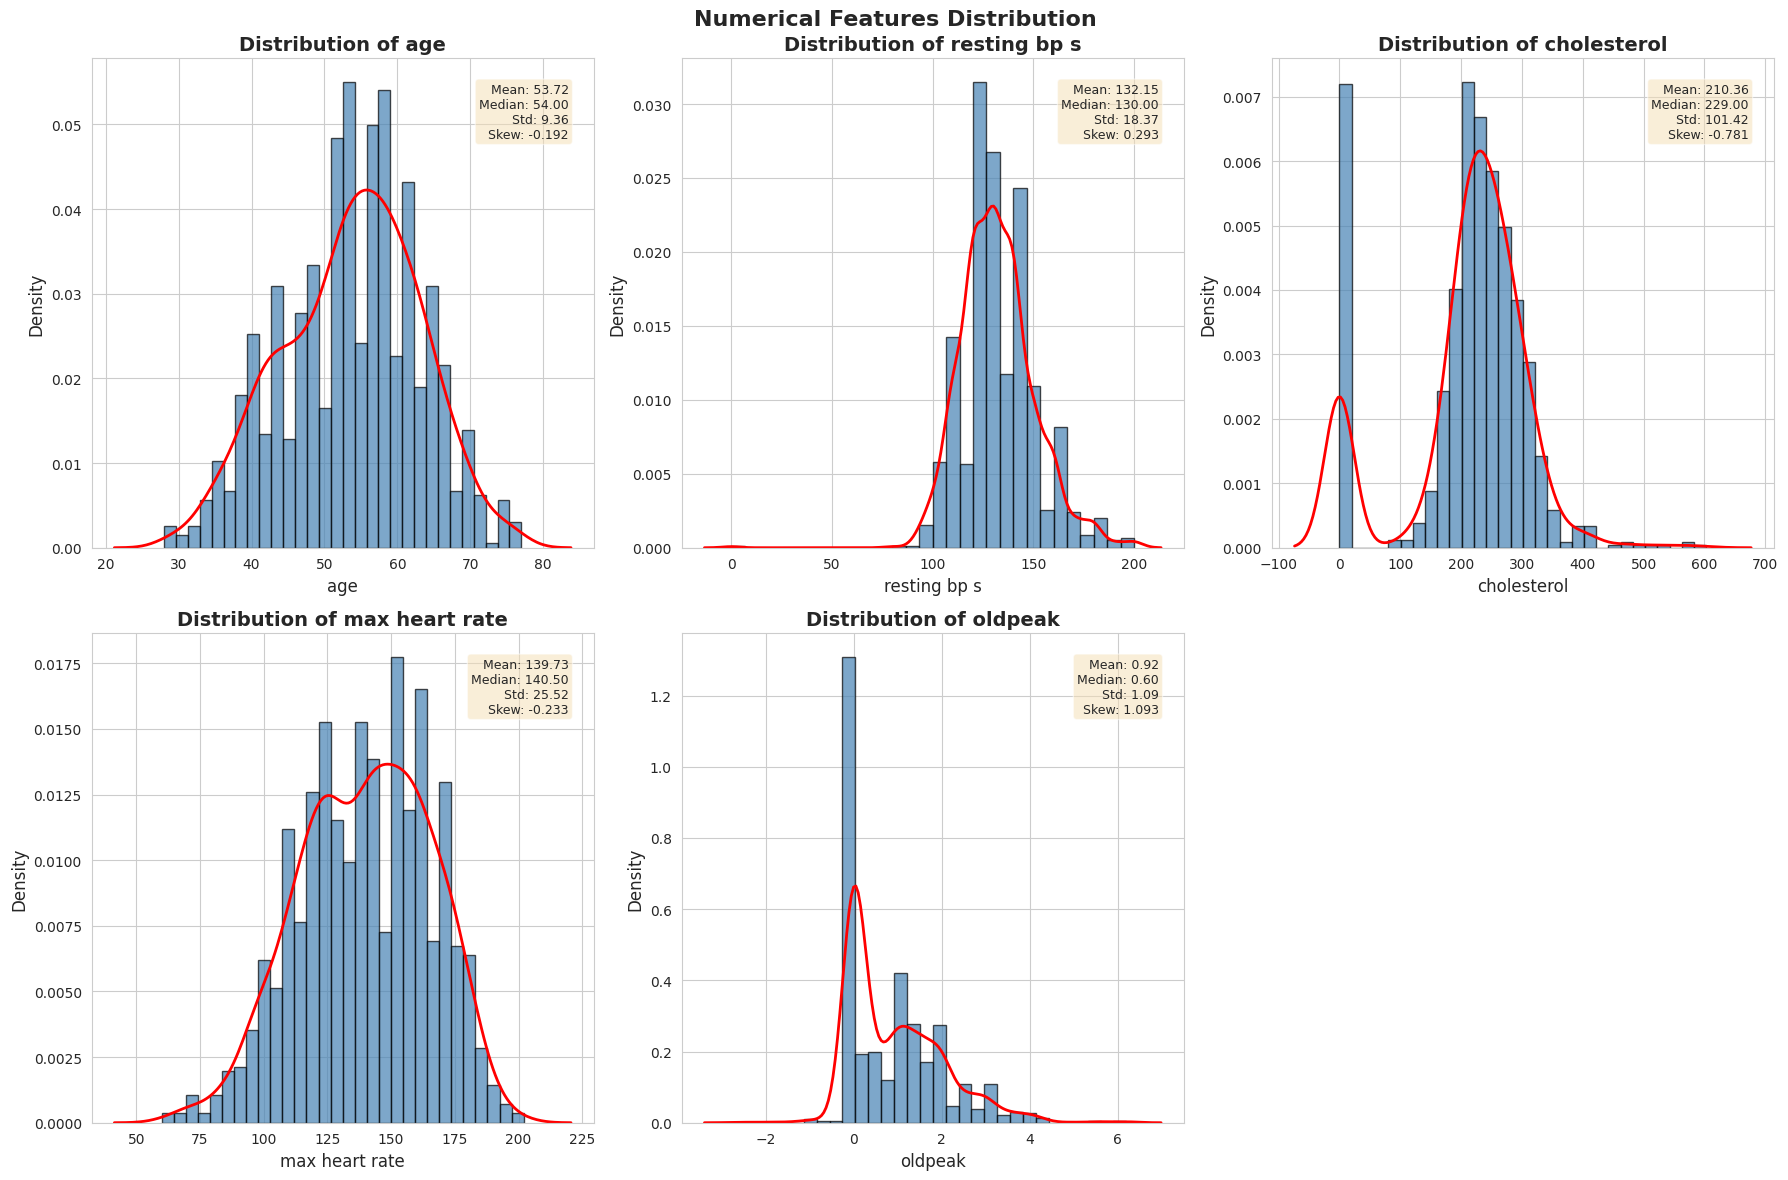

Saved: 2_Numerical_Distributions.png


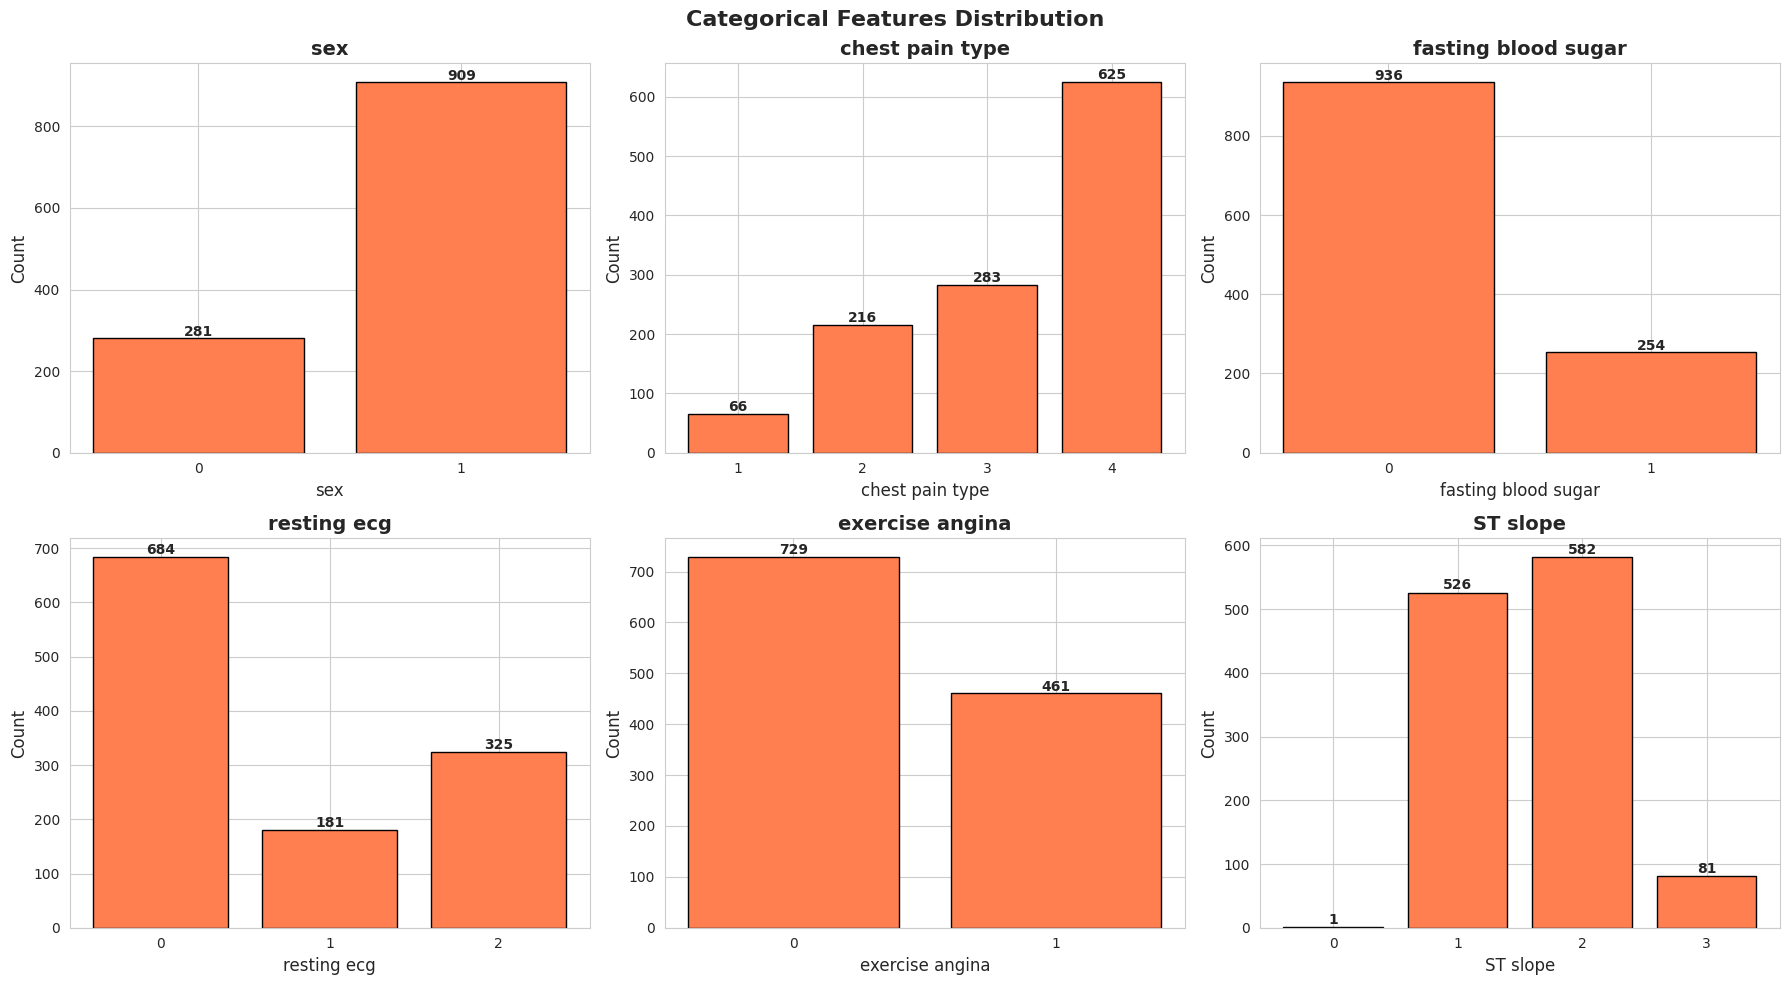

Saved: 3_Categorical_Distributions.png


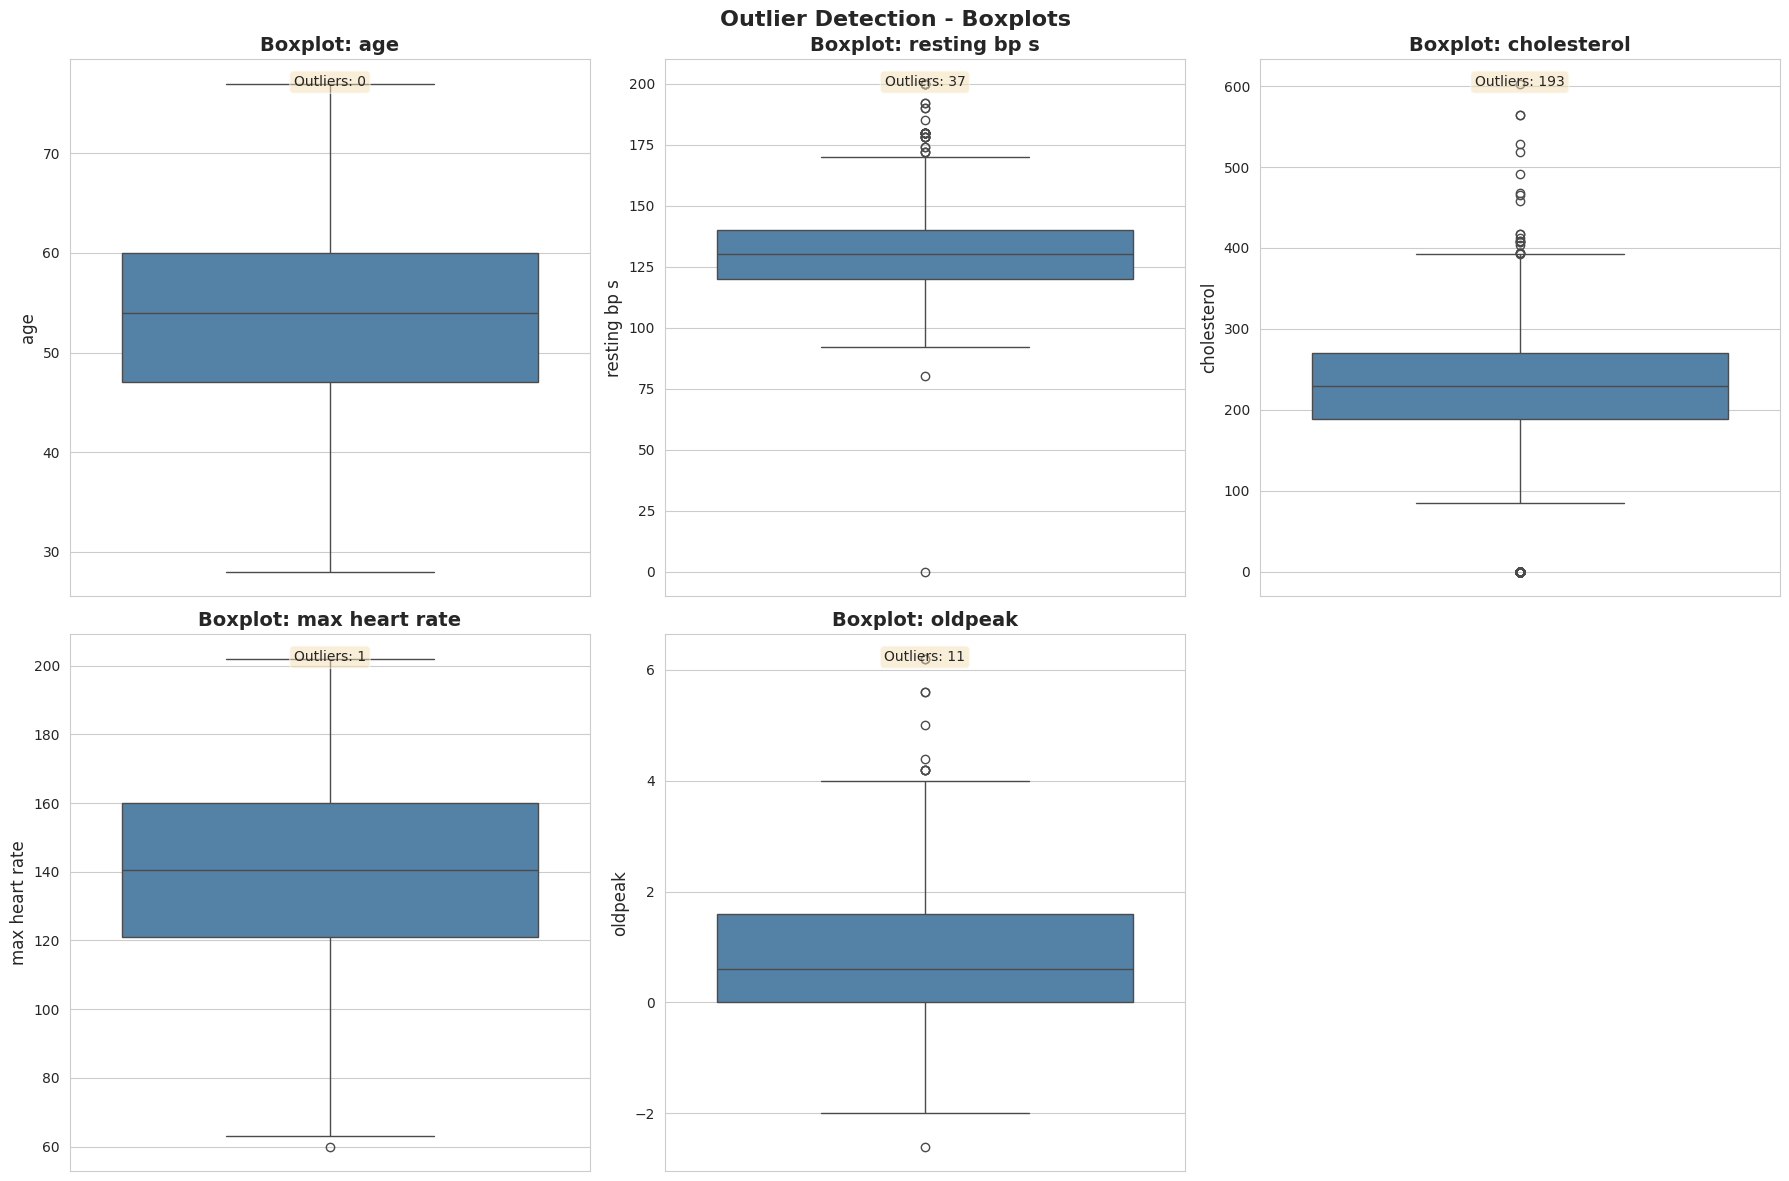

Saved: 4_Boxplots.png


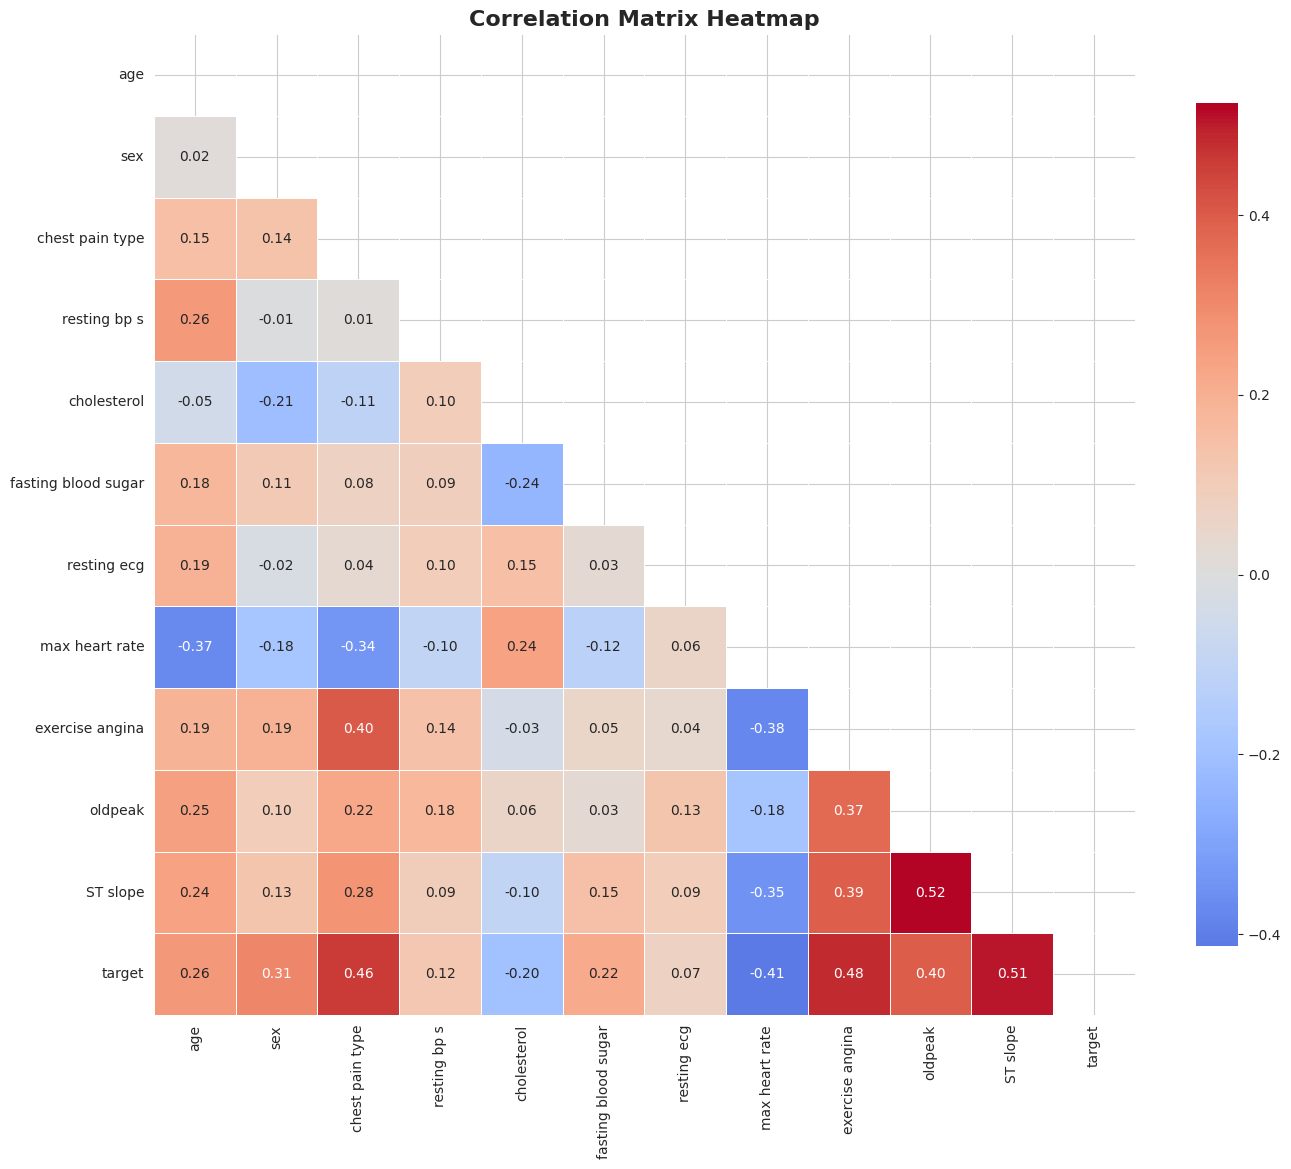

Saved: 5_Correlation_Matrix.png


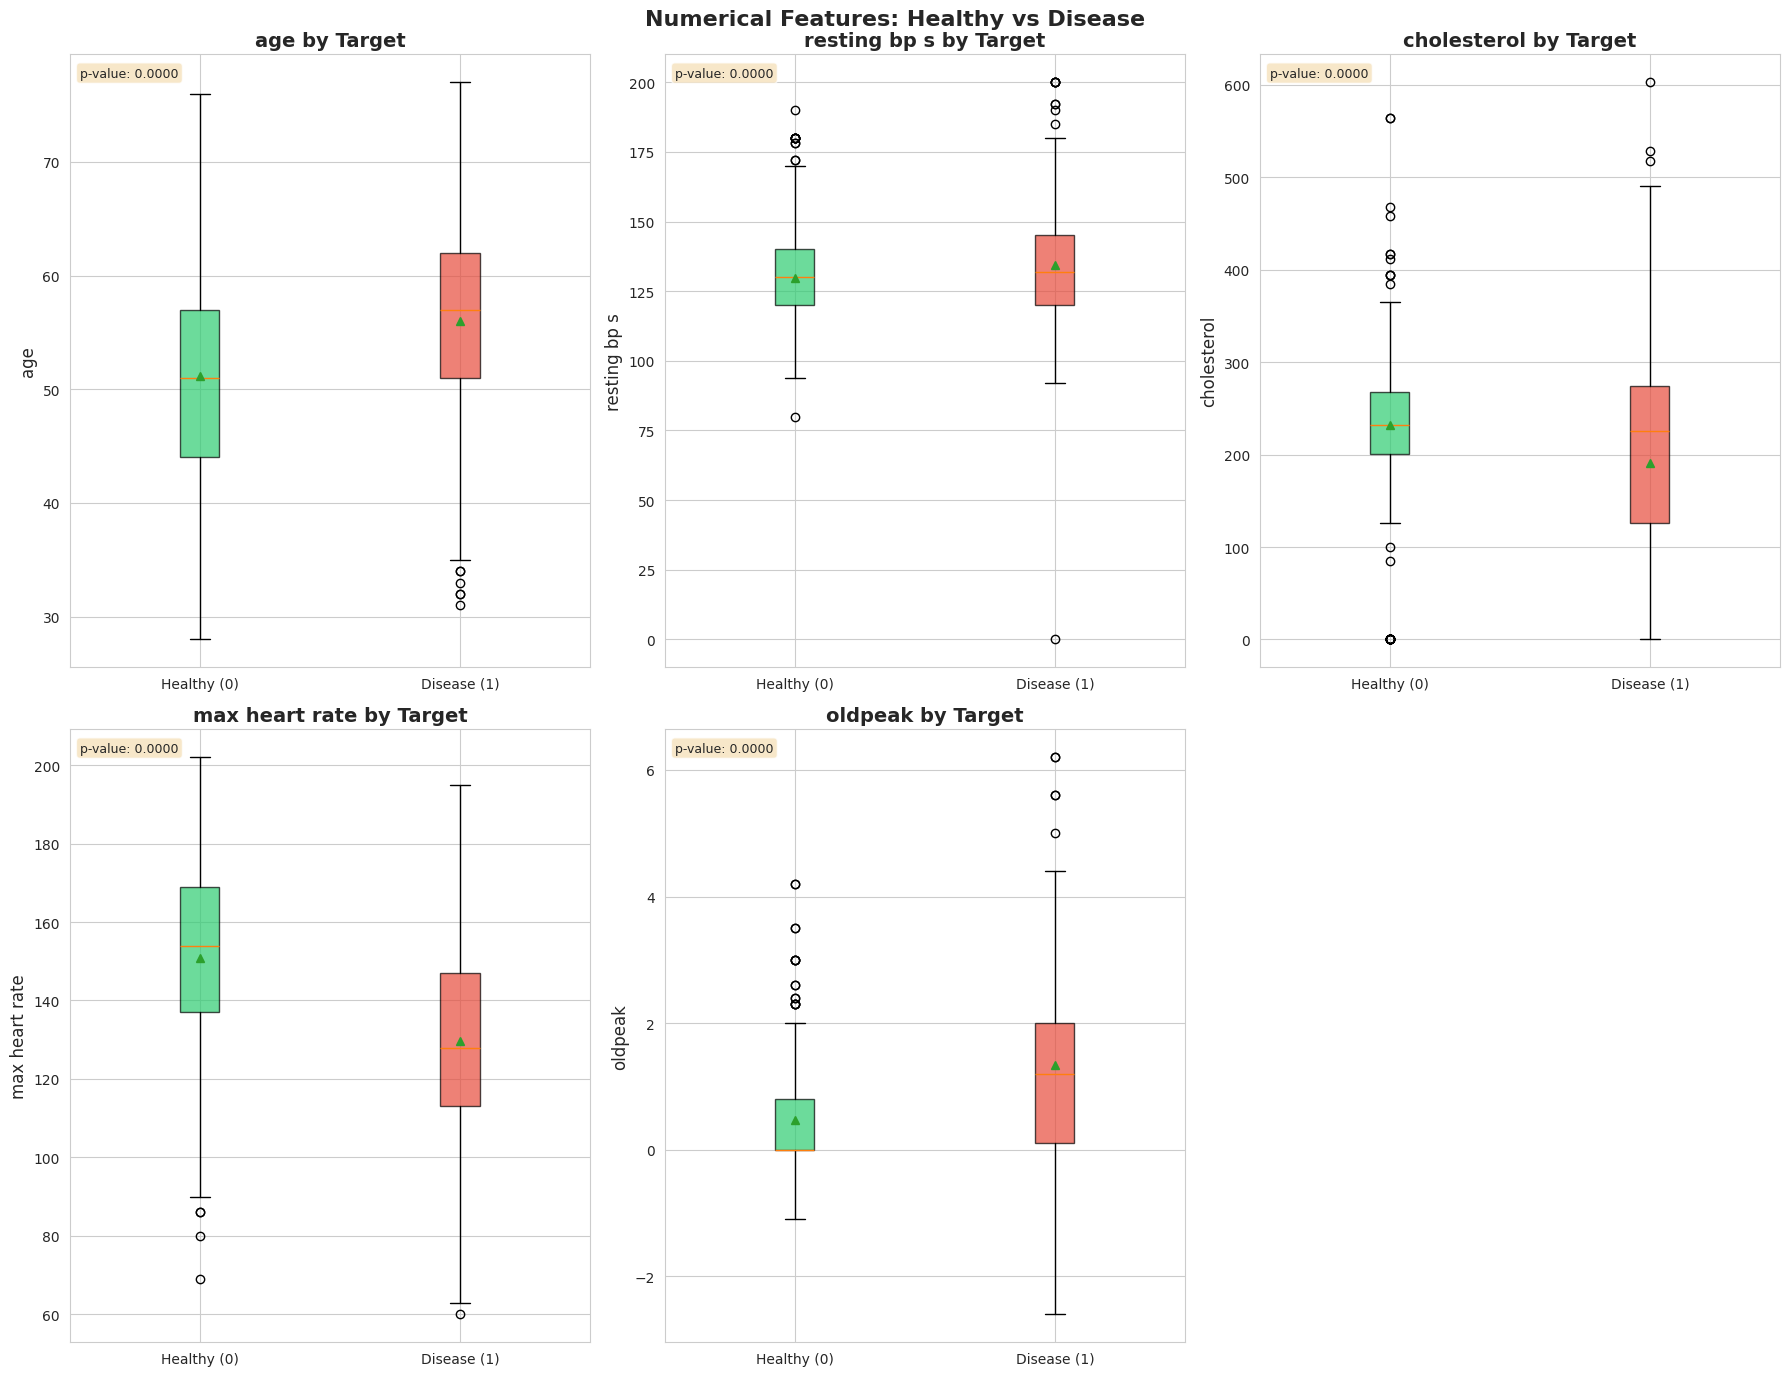

Saved: 6_Target_Comparison.png


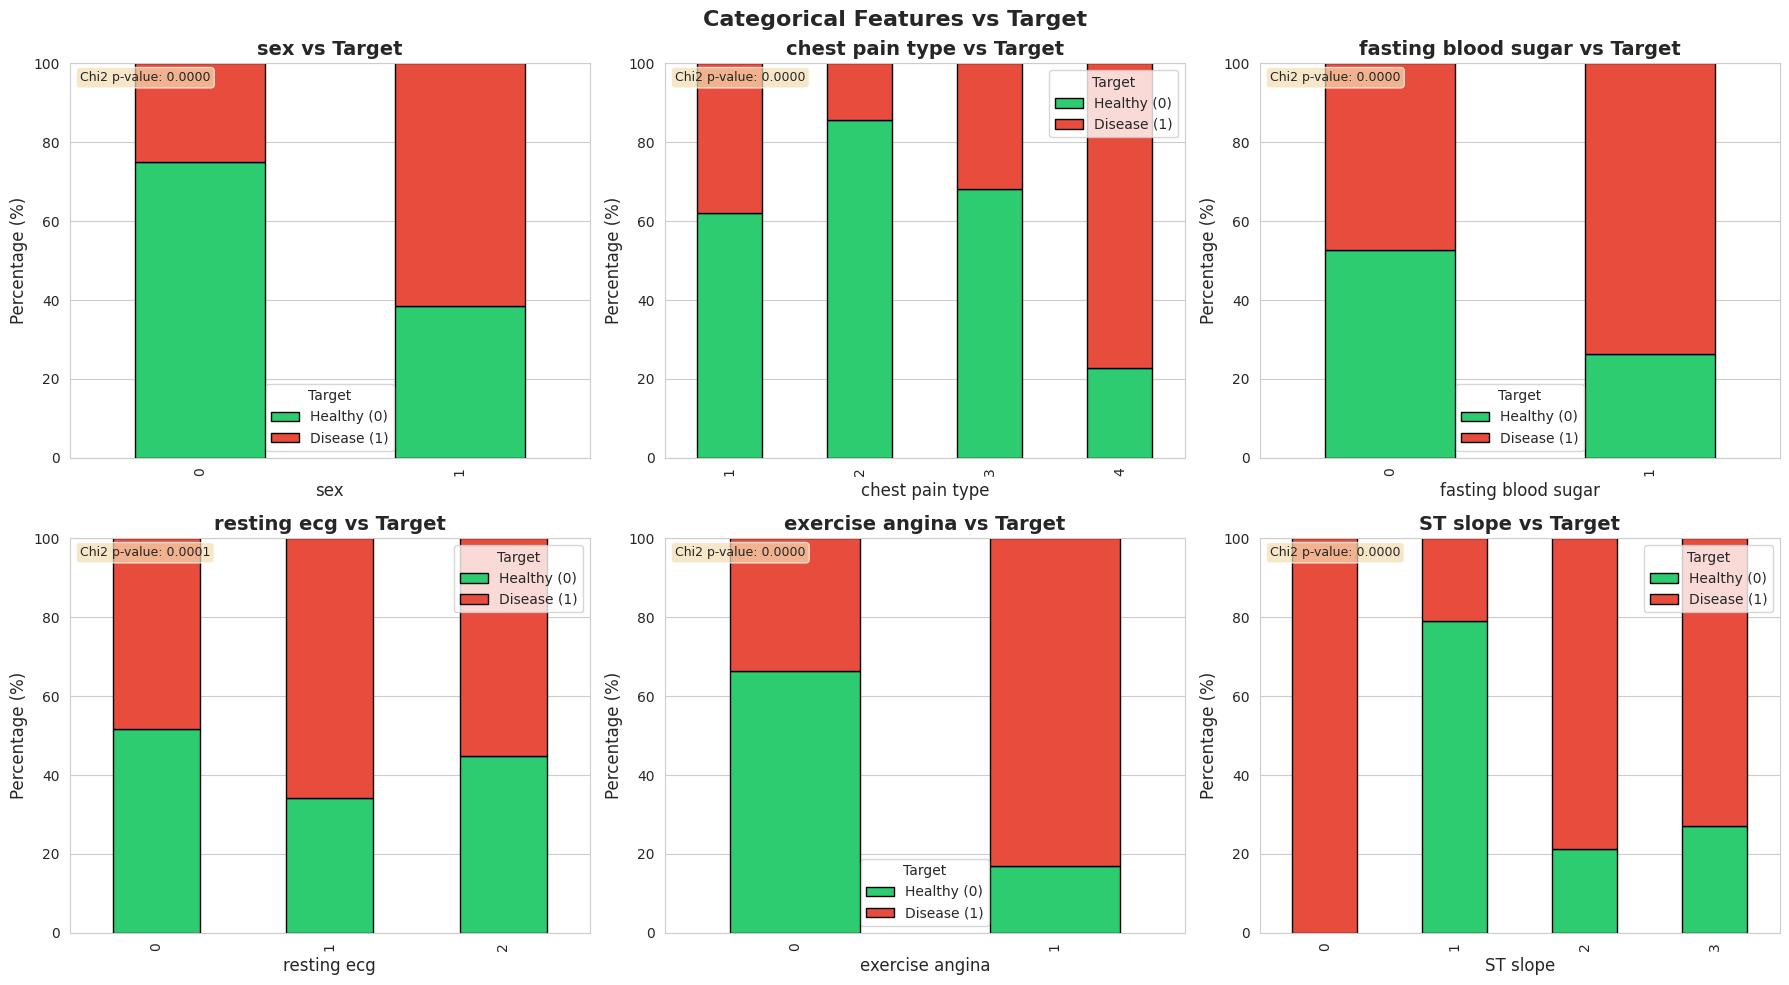

Saved: 7_Categorical_vs_Target.png


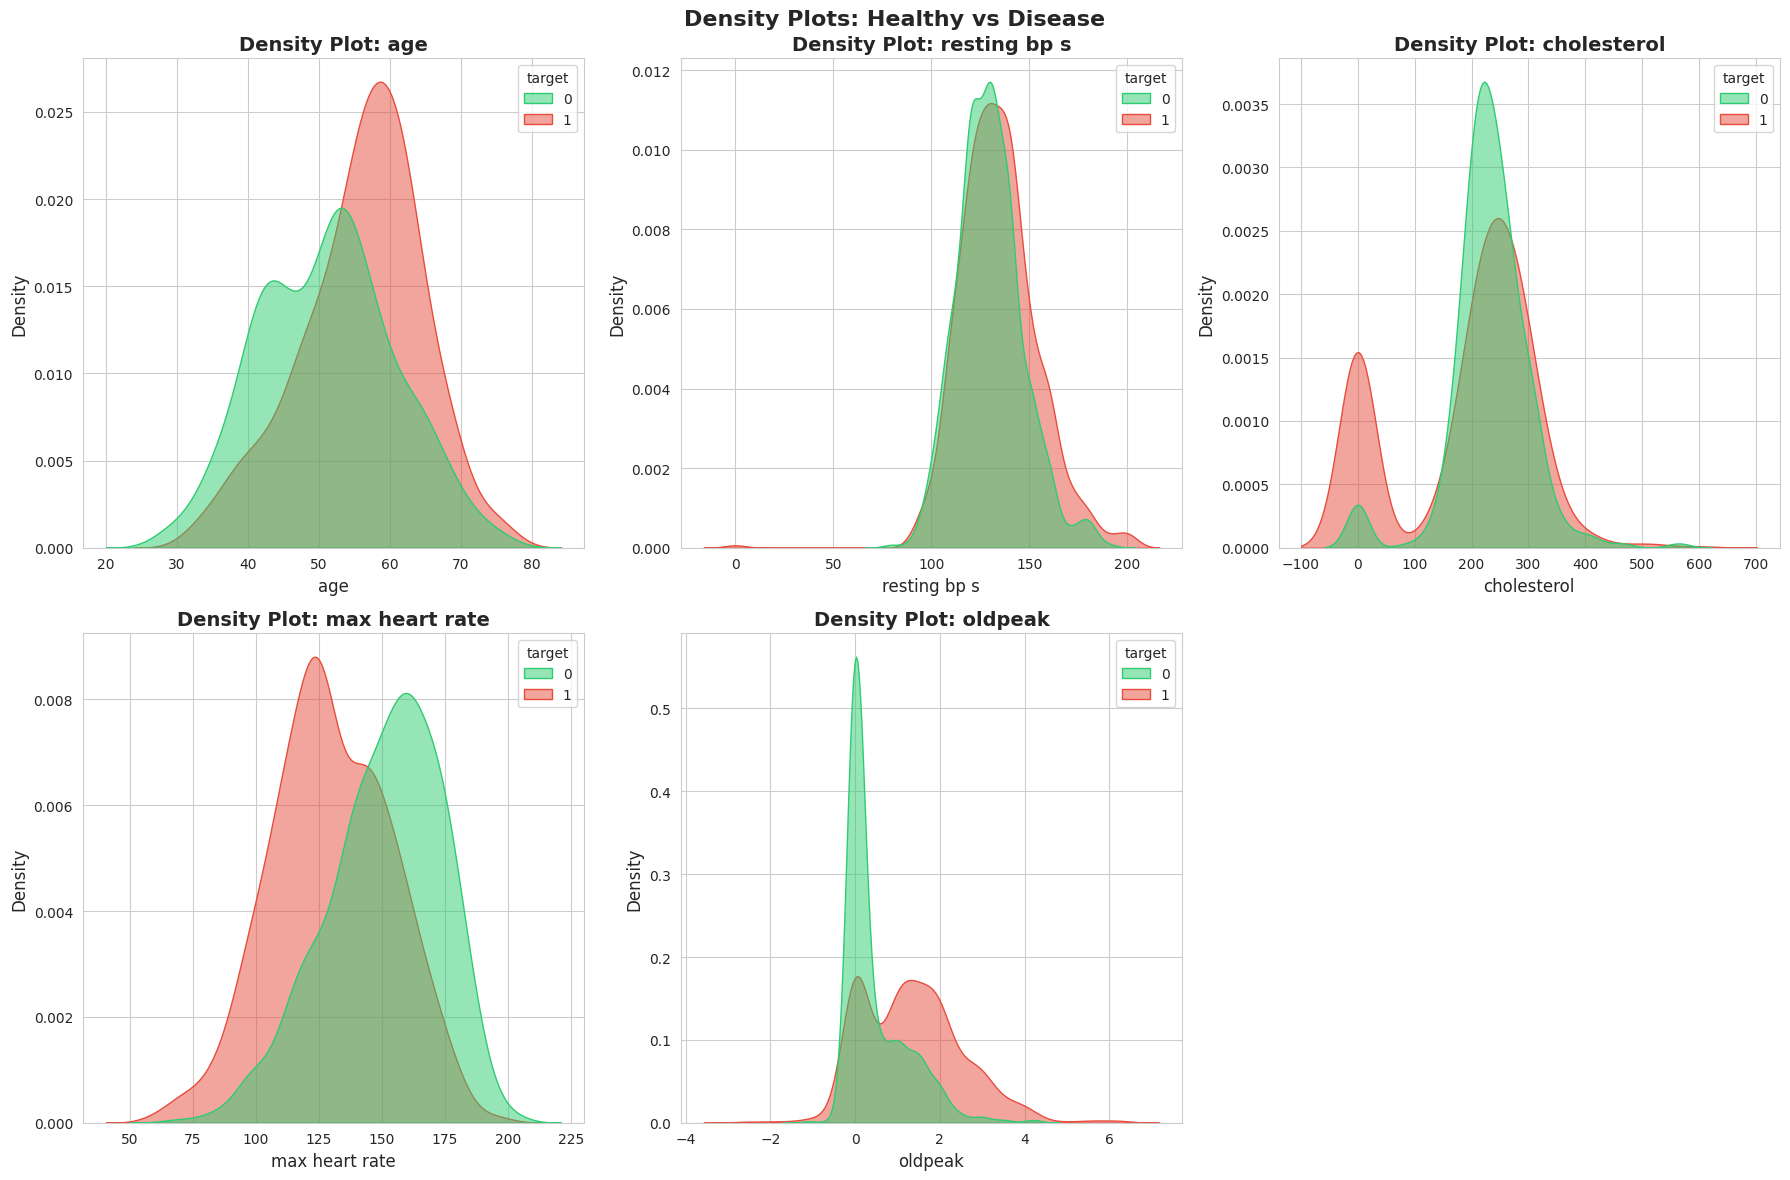

Saved: 8_Density_Plots.png


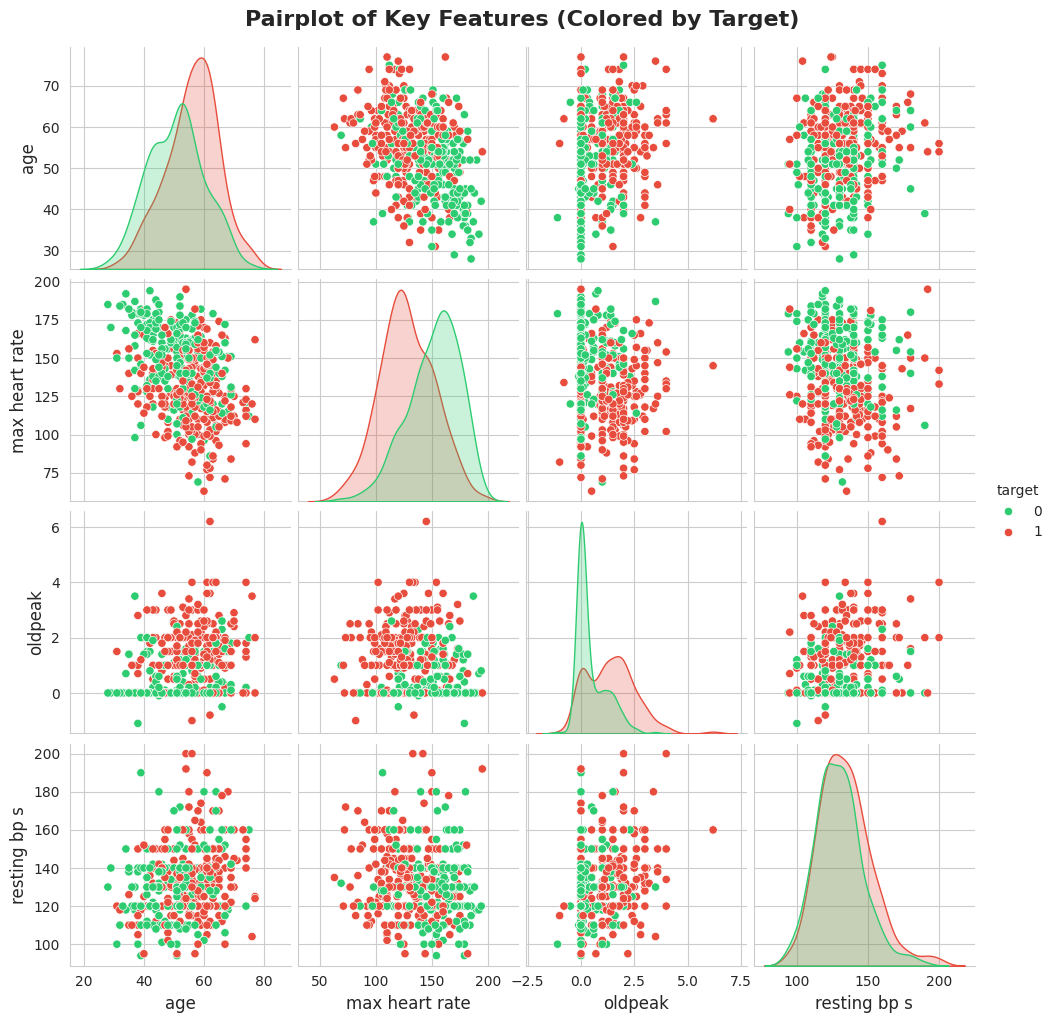

Saved: 9_Pairplot.png


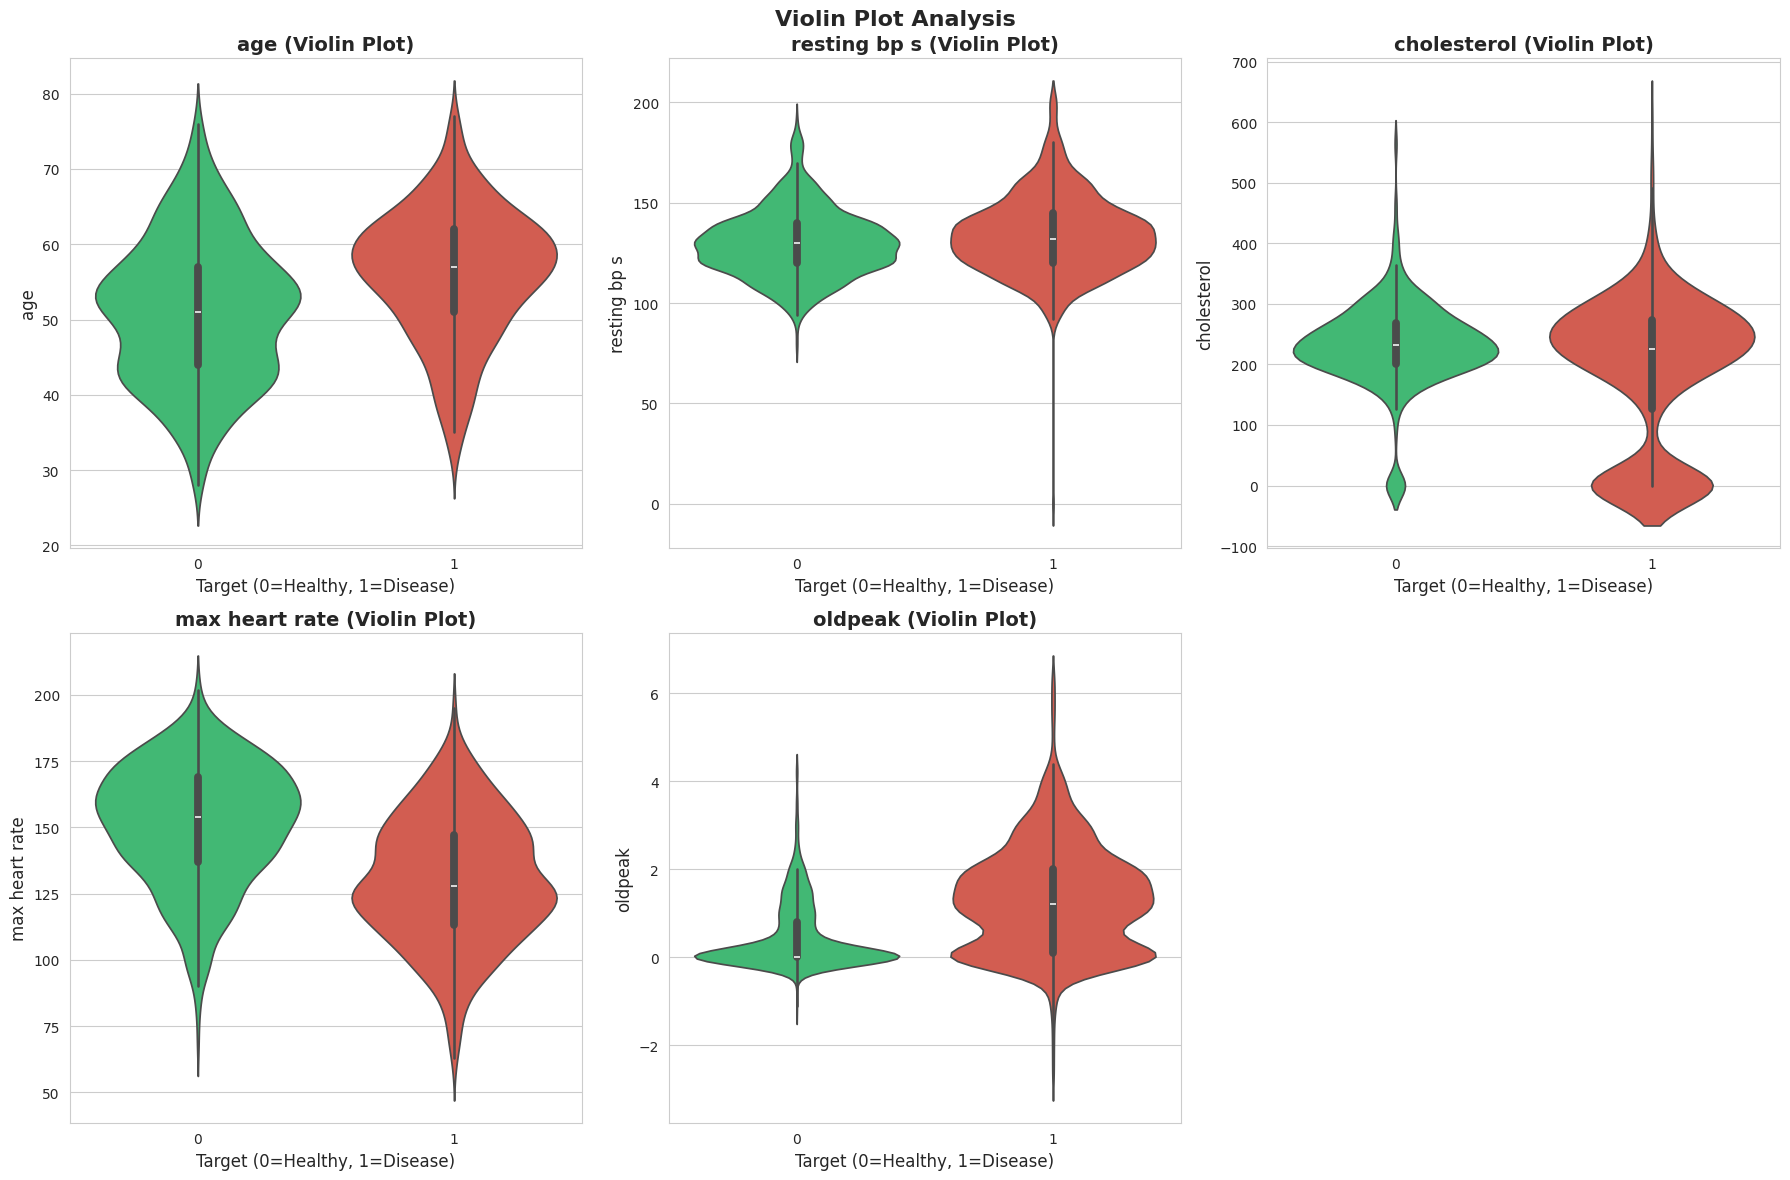

Saved: 10_Violin_Plots.png

All visualizations generated successfully!

Step 4: Generating Summary Report...

EDA SUMMARY REPORT - HEART DISEASE DATASET

DATASET OVERVIEW:
   - Total samples: 1190
   - Total features: 12
   - Missing values: 0
   - Duplicated rows: 272

TARGET DISTRIBUTION:
   - Healthy (0): 561 (47.1%)
   - Disease (1): 629 (52.9%)

NUMERICAL FEATURES:
   - age: Mean=53.72, Median=54.00, Std=9.36
   - resting bp s: Mean=132.15, Median=130.00, Std=18.37
   - cholesterol: Mean=210.36, Median=229.00, Std=101.42
   - max heart rate: Mean=139.73, Median=140.50, Std=25.52
   - oldpeak: Mean=0.92, Median=0.60, Std=1.09

TOP CORRELATIONS WITH TARGET:
   - ST slope: 0.5056
   - exercise angina: 0.4815
   - chest pain type: 0.4601
   - oldpeak: 0.3984
   - sex: 0.3113

OUTPUT FILES GENERATED:
   1. 1_Target_Distribution.png
   2. 2_Numerical_Distributions.png
   3. 3_Categorical_Distributions.png
   4. 4_Boxplots.png
   5. 5_Correlation_Matrix.png
   6. 6_Target_Comparison.png


In [ ]:
# ================================================
# HEART DISEASE DATA EXPLORER
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")

print("="*100)
print("OOP HEART DISEASE DATA EXPLORER")
print("Object-Oriented EDA Pipeline")
print("="*100)


class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.load_data()

    def load_data(self):
        try:
            self.df = pd.read_csv(self.file_path)
            print("Data loaded successfully!")
            print("Shape: {} rows x {} columns".format(self.df.shape[0], self.df.shape[1]))
        except FileNotFoundError:
            print("File not found at: {}".format(self.file_path))
            raise

    def get_info(self):
        print("\n" + "="*80)
        print("DATASET INFORMATION")
        print("="*80)
        print("\nShape: {} rows x {} columns".format(self.df.shape[0], self.df.shape[1]))
        print(self.df.head())
        print("\nColumn Names:")
        for i, col in enumerate(self.df.columns, 1):
            print("   {}. {}".format(i, col))
        print("\nData Types:")
        print(self.df.dtypes)

    def get_dataframe(self):
        return self.df


class DataAnalyzer:
    def __init__(self, df):
        self.df = df
        self.numerical_cols = None
        self.categorical_cols = None
        self.target_col = 'target'
        self.identify_column_types()

    def identify_column_types(self):
        self.numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = self.df.select_dtypes(include=['object']).columns.tolist()

        if self.target_col in self.numerical_cols:
            self.numerical_cols.remove(self.target_col)

        for col in self.numerical_cols[:]:
            if self.df[col].nunique() <= 10:
                self.categorical_cols.append(col)
                self.numerical_cols.remove(col)

        print("\nColumn Types Identified:")
        print("   Numerical: {} columns".format(len(self.numerical_cols)))
        print("   Categorical: {} columns".format(len(self.categorical_cols)))
        print("   Target: {}".format(self.target_col))

    def get_descriptive_stats(self):
        print("\n" + "="*80)
        print("DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
        print("="*80)
        if self.numerical_cols:
            print(self.df[self.numerical_cols].describe().round(2))

    def get_target_distribution(self):
        print("\n" + "="*80)
        print("TARGET VARIABLE DISTRIBUTION")
        print("="*80)

        counts = self.df[self.target_col].value_counts()
        pct = self.df[self.target_col].value_counts(normalize=True) * 100

        print("\nTarget Distribution:")
        for label, count in counts.items():
            name = "Healthy (0)" if label == 0 else "Disease (1)"
            print("   {}: {} ({:.1f}%)".format(name, count, pct[label]))

        return counts, pct

    def get_missing_values(self):
        print("\n" + "="*80)
        print("MISSING VALUES ANALYSIS")
        print("="*80)

        missing = self.df.isnull().sum()
        missing = missing[missing > 0]

        if len(missing) == 0:
            print("\nNo missing values found in the dataset!")
        else:
            print("\nMissing values found:")
            for col, count in missing.items():
                print("   - {}: {} ({:.2f}%)".format(col, count, count/len(self.df)*100))

        return missing

    def get_categorical_distributions(self):
        print("\n" + "="*80)
        print("CATEGORICAL FEATURES DISTRIBUTION")
        print("="*80)

        for col in self.categorical_cols:
            if col != self.target_col:
                print("\n{}:".format(col))
                for val, count in self.df[col].value_counts().items():
                    print("      {}: {} ({:.1f}%)".format(val, count, count/len(self.df)*100))

    def get_skewness_kurtosis(self):
        print("\n" + "="*80)
        print("SKEWNESS AND KURTOSIS")
        print("="*80)

        results = []
        for col in self.numerical_cols:
            skew_val = skew(self.df[col].dropna())
            kurt_val = kurtosis(self.df[col].dropna())
            results.append({
                'Feature': col,
                'Skewness': round(skew_val, 3),
                'Kurtosis': round(kurt_val, 3),
                'Distribution': 'Normal' if -0.5 < skew_val < 0.5 else 'Skewed'
            })
            print("\n{}:".format(col))
            print("   Skewness: {:.3f} ({})".format(skew_val, 'Normal' if -0.5 < skew_val < 0.5 else 'Skewed'))
            print("   Kurtosis: {:.3f}".format(kurt_val))

        return pd.DataFrame(results)

    def get_correlation_with_target(self):
        print("\n" + "="*80)
        print("CORRELATION WITH TARGET")
        print("="*80)

        corr_df = self.df.corr()
        corr_with_target = corr_df[self.target_col].drop(self.target_col).sort_values(ascending=False)

        print("\nFeature Correlations with Heart Disease:")
        for feature, corr in corr_with_target.items():
            direction = "+" if corr > 0 else "-" if corr < 0 else "="
            print("   {} {}: {:.4f}".format(direction, feature, corr))

        return corr_with_target

    def get_outlier_summary(self):
        print("\n" + "="*80)
        print("OUTLIER DETECTION (IQR Method)")
        print("="*80)

        outlier_summary = []
        for col in self.numerical_cols:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = self.df[(self.df[col] < lower_bound) | (self.df[col] > upper_bound)]
            outlier_count = len(outliers)
            outlier_pct = (outlier_count / len(self.df)) * 100

            outlier_summary.append({
                'Feature': col,
                'Q1': round(Q1, 2),
                'Q3': round(Q3, 2),
                'IQR': round(IQR, 2),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Outlier Count': outlier_count,
                'Outlier %': round(outlier_pct, 2)
            })

        summary_df = pd.DataFrame(outlier_summary)
        print("\nOutlier Summary:")
        print(summary_df.to_string(index=False))

        return summary_df

    def get_zero_value_analysis(self):
        print("\n" + "="*80)
        print("ZERO VALUES ANALYSIS")
        print("="*80)

        zero_analysis = []
        for col in self.numerical_cols:
            zero_count = (self.df[col] == 0).sum()
            if zero_count > 0:
                zero_analysis.append({
                    'Feature': col,
                    'Zero Count': zero_count,
                    'Zero %': round(zero_count/len(self.df)*100, 2)
                })
                print("\n{}:".format(col))
                print("   Zero values: {} ({:.2f}%)".format(zero_count, zero_count/len(self.df)*100))

        if not zero_analysis:
            print("\nNo zero values found in numerical features.")

        return pd.DataFrame(zero_analysis)


class DataVisualizer:
    def __init__(self, df, analyzer):
        self.df = df
        self.analyzer = analyzer
        self.numerical_cols = analyzer.numerical_cols
        self.categorical_cols = analyzer.categorical_cols
        self.target_col = analyzer.target_col
        self.output_dir = '/content/'

    def plot_target_distribution(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        counts = self.df[self.target_col].value_counts()
        labels = ['Healthy (0)', 'Disease (1)']
        colors_target = ['#2ecc71', '#e74c3c']

        bars = axes[0].bar(labels, counts.values, color=colors_target, edgecolor='black')
        axes[0].set_title('Target Distribution', fontweight='bold')
        axes[0].set_ylabel('Number of Patients')
        for bar, count in zip(bars, counts.values):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        '{} ({:.1f}%)'.format(count, count/len(self.df)*100),
                        ha='center', fontweight='bold')

        axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
                    colors=colors_target, startangle=90, explode=(0.05, 0))
        axes[1].set_title('Target Distribution (Pie Chart)', fontweight='bold')

        plt.tight_layout()
        plt.savefig('{}1_Target_Distribution.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 1_Target_Distribution.png")

    def plot_numerical_distributions(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, col in enumerate(self.numerical_cols):
            if i < len(axes):
                axes[i].hist(self.df[col], bins=30, color='steelblue', edgecolor='black',
                            alpha=0.7, density=True)
                sns.kdeplot(self.df[col], color='red', linewidth=2, ax=axes[i])
                axes[i].set_title('Distribution of {}'.format(col), fontweight='bold')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Density')

                stats_text = "Mean: {:.2f}\nMedian: {:.2f}\nStd: {:.2f}\nSkew: {:.3f}".format(
                    self.df[col].mean(), self.df[col].median(),
                    self.df[col].std(), skew(self.df[col]))
                axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes,
                             fontsize=9, verticalalignment='top', horizontalalignment='right',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Numerical Features Distribution', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}2_Numerical_Distributions.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 2_Numerical_Distributions.png")

    def plot_categorical_distributions(self):
        cat_cols = [col for col in self.categorical_cols if col != self.target_col]
        n_cols = len(cat_cols)
        n_rows = (n_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, min(3, n_cols), figsize=(18, 5*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

        for i, col in enumerate(cat_cols):
            if i < len(axes):
                counts = self.df[col].value_counts().sort_index()
                bars = axes[i].bar(counts.index.astype(str), counts.values,
                                   color='coral', edgecolor='black')
                axes[i].set_title(col, fontweight='bold')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Count')

                for bar, count in zip(bars, counts.values):
                    axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                                str(count), ha='center', fontweight='bold')

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}3_Categorical_Distributions.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 3_Categorical_Distributions.png")

    def plot_boxplots(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, col in enumerate(self.numerical_cols):
            if i < len(axes):
                sns.boxplot(data=self.df, y=col, ax=axes[i], color='steelblue')
                axes[i].set_title('Boxplot: {}'.format(col), fontweight='bold')
                axes[i].set_ylabel(col)

                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR
                outlier_count = ((self.df[col] < lower) | (self.df[col] > upper)).sum()
                axes[i].text(0.5, 0.95, 'Outliers: {}'.format(outlier_count),
                             transform=axes[i].transAxes, ha='center', fontsize=10,
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Outlier Detection - Boxplots', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}4_Boxplots.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 4_Boxplots.png")

    def plot_correlation_heatmap(self):
        corr_matrix = self.df.corr()

        plt.figure(figsize=(14, 12))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}5_Correlation_Matrix.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 5_Correlation_Matrix.png")

    def plot_target_comparison(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 14))
        axes = axes.flatten()

        for i, col in enumerate(self.numerical_cols):
            if i < len(axes):
                data_healthy = self.df[self.df[self.target_col] == 0][col]
                data_disease = self.df[self.df[self.target_col] == 1][col]

                bp = axes[i].boxplot([data_healthy, data_disease],
                                     labels=['Healthy (0)', 'Disease (1)'],
                                     patch_artist=True, showmeans=True)

                for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)

                axes[i].set_title('{} by Target'.format(col), fontweight='bold')
                axes[i].set_ylabel(col)

                t_stat, p_value = stats.ttest_ind(data_healthy, data_disease)
                axes[i].text(0.02, 0.98, 'p-value: {:.4f}'.format(p_value), transform=axes[i].transAxes,
                             fontsize=9, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Numerical Features: Healthy vs Disease', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}6_Target_Comparison.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 6_Target_Comparison.png")

    def plot_categorical_vs_target(self):
        cat_cols = [col for col in self.categorical_cols if col != self.target_col]
        n_cols = len(cat_cols)
        n_rows = (n_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, min(3, n_cols), figsize=(18, 5*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

        for i, col in enumerate(cat_cols):
            if i < len(axes):
                ct = pd.crosstab(self.df[col], self.df[self.target_col], normalize='index') * 100
                ct.plot(kind='bar', stacked=True, ax=axes[i],
                        color=['#2ecc71', '#e74c3c'], edgecolor='black')
                axes[i].set_title('{} vs Target'.format(col), fontweight='bold')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Percentage (%)')
                axes[i].legend(title='Target', labels=['Healthy (0)', 'Disease (1)'])
                axes[i].set_ylim(0, 100)

                contingency = pd.crosstab(self.df[col], self.df[self.target_col])
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                axes[i].text(0.02, 0.98, 'Chi2 p-value: {:.4f}'.format(p_value), transform=axes[i].transAxes,
                             fontsize=9, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Categorical Features vs Target', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}7_Categorical_vs_Target.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 7_Categorical_vs_Target.png")

    def plot_density_plots(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, col in enumerate(self.numerical_cols):
            if i < len(axes):
                sns.kdeplot(data=self.df, x=col, hue=self.target_col, ax=axes[i],
                           palette=['#2ecc71', '#e74c3c'], fill=True, alpha=0.5)
                axes[i].set_title('Density Plot: {}'.format(col), fontweight='bold')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Density')

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Density Plots: Healthy vs Disease', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}8_Density_Plots.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 8_Density_Plots.png")

    def plot_pairplot(self):
        key_features = ['age', 'max heart rate', 'oldpeak', 'resting bp s', self.target_col]
        sample_df = self.df[key_features].copy()

        if len(sample_df) > 500:
            sample_df = sample_df.sample(500, random_state=42)

        sns.pairplot(sample_df, hue=self.target_col, palette=['#2ecc71', '#e74c3c'], diag_kind='kde')
        plt.suptitle('Pairplot of Key Features (Colored by Target)', y=1.02, fontsize=16, fontweight='bold')
        plt.savefig('{}9_Pairplot.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 9_Pairplot.png")

    def plot_violin_plots(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, col in enumerate(self.numerical_cols):
            if i < len(axes):
                sns.violinplot(data=self.df, x=self.target_col, y=col, ax=axes[i],
                              palette=['#2ecc71', '#e74c3c'], split=False)
                axes[i].set_title('{} (Violin Plot)'.format(col), fontweight='bold')
                axes[i].set_xlabel('Target (0=Healthy, 1=Disease)')
                axes[i].set_ylabel(col)

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Violin Plot Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('{}10_Violin_Plots.png'.format(self.output_dir), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: 10_Violin_Plots.png")

    def generate_all_plots(self):
        print("\n" + "="*80)
        print("GENERATING ALL VISUALIZATIONS")
        print("="*80)

        self.plot_target_distribution()
        self.plot_numerical_distributions()
        self.plot_categorical_distributions()
        self.plot_boxplots()
        self.plot_correlation_heatmap()
        self.plot_target_comparison()
        self.plot_categorical_vs_target()
        self.plot_density_plots()
        self.plot_pairplot()
        self.plot_violin_plots()

        print("\nAll visualizations generated successfully!")


class EDAPipeline:
    def __init__(self, file_path):
        self.file_path = file_path
        self.loader = None
        self.analyzer = None
        self.visualizer = None

    def run(self):
        print("\n" + "="*100)
        print("STARTING EDA PIPELINE")
        print("="*100)

        print("\nStep 1: Loading Data...")
        self.loader = DataLoader(self.file_path)
        df = self.loader.get_dataframe()

        print("\nStep 2: Analyzing Data...")
        self.analyzer = DataAnalyzer(df)

        self.loader.get_info()
        self.analyzer.get_descriptive_stats()
        self.analyzer.get_target_distribution()
        self.analyzer.get_missing_values()
        self.analyzer.get_categorical_distributions()
        self.analyzer.get_skewness_kurtosis()
        self.analyzer.get_correlation_with_target()
        self.analyzer.get_outlier_summary()
        self.analyzer.get_zero_value_analysis()

        print("\nStep 3: Visualizing Data...")
        self.visualizer = DataVisualizer(df, self.analyzer)
        self.visualizer.generate_all_plots()

        print("\nStep 4: Generating Summary Report...")
        self._generate_summary_report()

        print("\n" + "="*100)
        print("EDA PIPELINE COMPLETED SUCCESSFULLY!")
        print("All outputs saved in /content/ directory")
        print("="*100)

    def _generate_summary_report(self):
        df = self.loader.get_dataframe()

        report = "\n"
        report += "="*80 + "\n"
        report += "EDA SUMMARY REPORT - HEART DISEASE DATASET\n"
        report += "="*80 + "\n\n"

        report += "DATASET OVERVIEW:\n"
        report += "   - Total samples: {}\n".format(len(df))
        report += "   - Total features: {}\n".format(df.shape[1])
        report += "   - Missing values: {}\n".format(df.isnull().sum().sum())
        report += "   - Duplicated rows: {}\n\n".format(df.duplicated().sum())

        report += "TARGET DISTRIBUTION:\n"
        counts = df['target'].value_counts()
        pct = df['target'].value_counts(normalize=True) * 100
        report += "   - Healthy (0): {} ({:.1f}%)\n".format(counts[0], pct[0])
        report += "   - Disease (1): {} ({:.1f}%)\n\n".format(counts[1], pct[1])

        report += "NUMERICAL FEATURES:\n"
        for col in self.analyzer.numerical_cols:
            report += "   - {}: Mean={:.2f}, Median={:.2f}, Std={:.2f}\n".format(
                col, df[col].mean(), df[col].median(), df[col].std())

        report += "\nTOP CORRELATIONS WITH TARGET:\n"
        corr = df.corr()['target'].drop('target').sort_values(ascending=False)
        for feature, value in corr.head(5).items():
            report += "   - {}: {:.4f}\n".format(feature, value)

        report += "\nOUTPUT FILES GENERATED:\n"
        report += "   1. 1_Target_Distribution.png\n"
        report += "   2. 2_Numerical_Distributions.png\n"
        report += "   3. 3_Categorical_Distributions.png\n"
        report += "   4. 4_Boxplots.png\n"
        report += "   5. 5_Correlation_Matrix.png\n"
        report += "   6. 6_Target_Comparison.png\n"
        report += "   7. 7_Categorical_vs_Target.png\n"
        report += "   8. 8_Density_Plots.png\n"
        report += "   9. 9_Pairplot.png\n"
        report += "   10. 10_Violin_Plots.png\n"

        report += "\n" + "="*80 + "\n"
        report += "EDA Complete! Data is ready for modeling.\n"
        report += "="*80 + "\n"

        print(report)

        with open('/content/EDA_Summary_Report_OOP.txt', 'w', encoding='utf-8') as f:
            f.write(report)
        print("Saved: EDA_Summary_Report_OOP.txt")


if __name__ == "__main__":
    pipeline = EDAPipeline('/content/heart_statlog_cleveland_hungary_final.csv')
    pipeline.run()

DATA CLEANING & FEATURE SELECTION

DATA CLEANING & FEATURE SELECTION PIPELINE

[1] LOADING DATA
----------------------------------------
Original shape: 1190 rows, 12 columns

[2] REMOVING DUPLICATES
----------------------------------------
Duplicates before: 272
Duplicates after: 0
Rows removed: 272
New shape: 918 rows, 12 columns

[3] HANDLING ZERO VALUES WITH KNN IMPUTER
----------------------------------------
Columns with zero values: ['resting bp s', 'cholesterol']
  resting bp s: 1 zeros (0.11%)
  cholesterol: 172 zeros (18.74%)

Replaced zeros with NaN for KNN imputation

Applying KNN Imputer (k=5)...

Checking imputation results:
  resting bp s: 0 zeros, 0 NaN
  cholesterol: 0 zeros, 0 NaN

[4] VISUALIZING BEFORE AND AFTER CLEANING
----------------------------------------


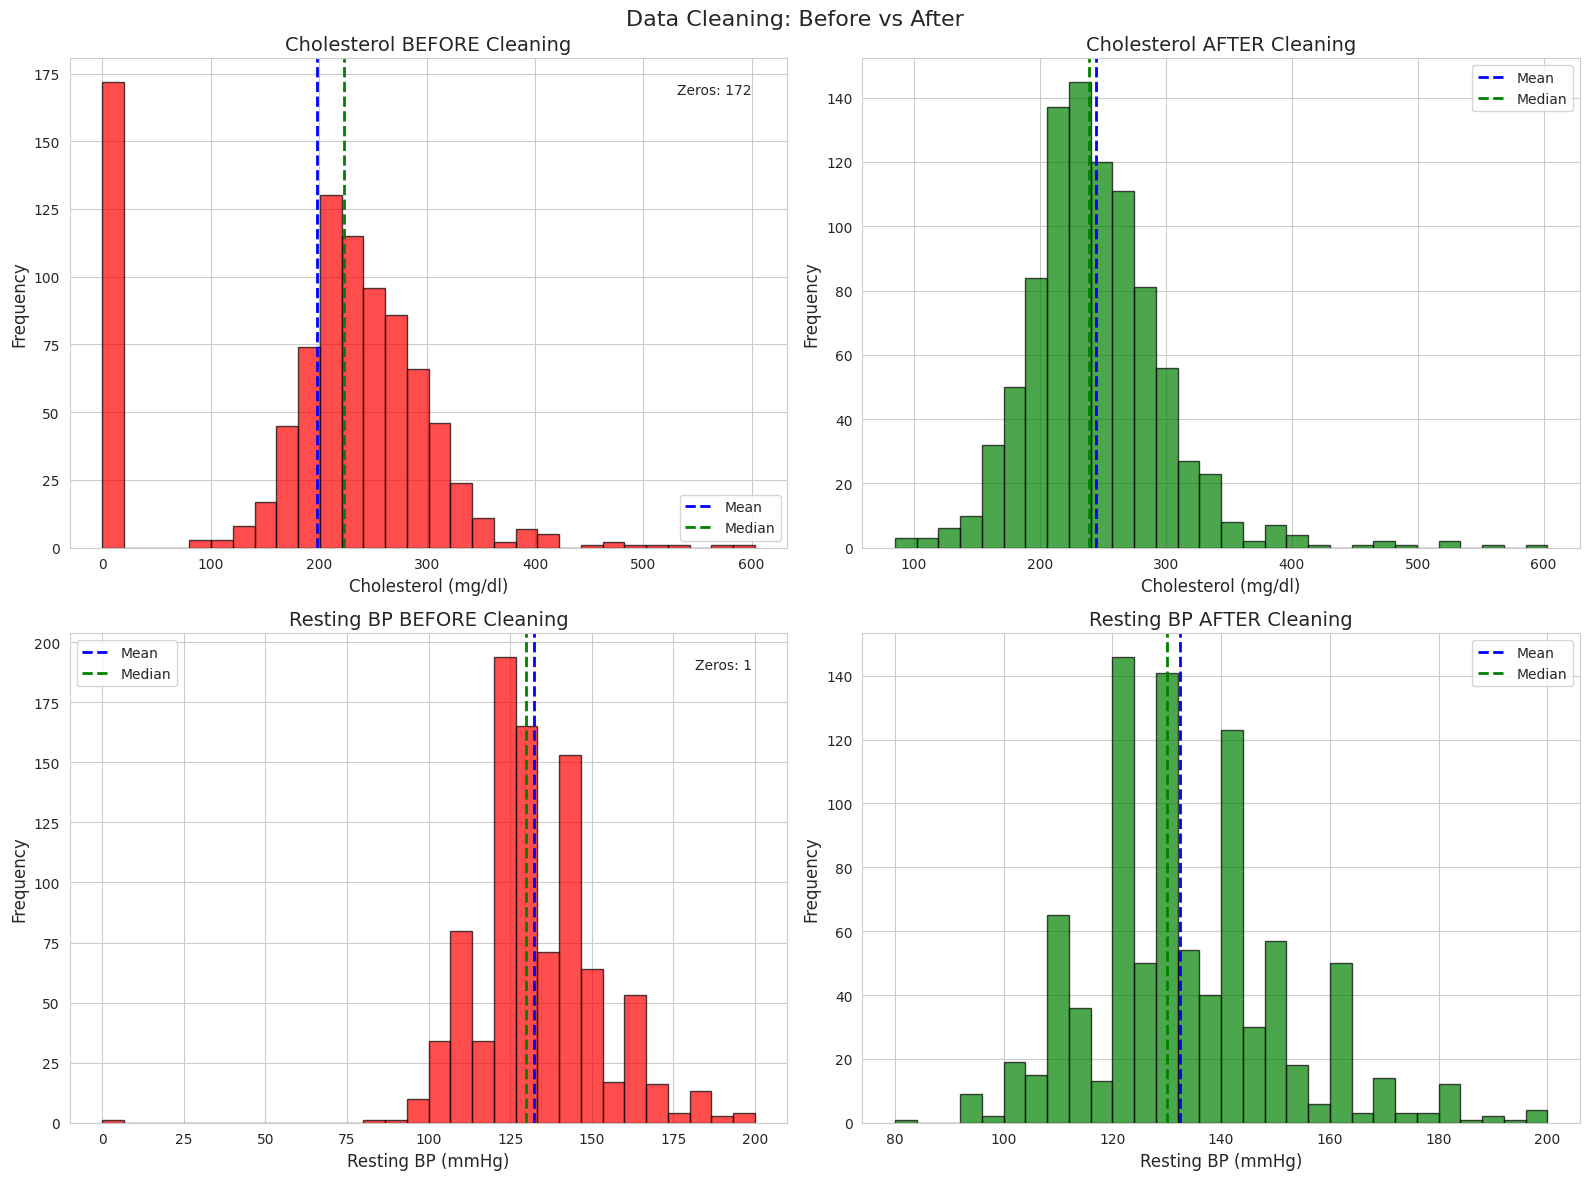

Saved: cleaning_comparison.png

[5] FEATURE SELECTION (5 METHODS)
----------------------------------------

Method 1: Mutual Information Scores
            Feature  MI_Score
           ST slope  0.203386
    exercise angina  0.135266
    chest pain type  0.125702
            oldpeak  0.093727
     max heart rate  0.074047
                sex  0.055611
        cholesterol  0.044554
                age  0.033702
       resting bp s  0.028804
fasting blood sugar  0.026991
        resting ecg  0.000000

Method 2: Random Forest Feature Importance
            Feature  RF_Importance
           ST slope       0.234153
    chest pain type       0.127354
            oldpeak       0.114046
     max heart rate       0.106949
    exercise angina       0.085112
        cholesterol       0.085098
                age       0.081260
       resting bp s       0.073236
                sex       0.037779
fasting blood sugar       0.030503
        resting ecg       0.024509

Method 3: SelectKBest F-Score
 

In [ ]:
# ================================================
# HEART DISEASE - DATA CLEANING & FEATURE SELECTION
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DATA CLEANING & FEATURE SELECTION PIPELINE")
print("="*80)

# ================================================
# 1. LOAD DATA
# ================================================
print("\n[1] LOADING DATA")
print("-"*40)

df = pd.read_csv('/content/heart_statlog_cleveland_hungary_final.csv')
print("Original shape: {} rows, {} columns".format(df.shape[0], df.shape[1]))

# ================================================
# 2. REMOVE DUPLICATES
# ================================================
print("\n[2] REMOVING DUPLICATES")
print("-"*40)

duplicates_before = df.duplicated().sum()
print("Duplicates before: {}".format(duplicates_before))

df = df.drop_duplicates()
duplicates_after = df.duplicated().sum()
print("Duplicates after: {}".format(duplicates_after))
print("Rows removed: {}".format(duplicates_before - duplicates_after))
print("New shape: {} rows, {} columns".format(df.shape[0], df.shape[1]))

# ================================================
# 3. HANDLE ZERO VALUES WITH KNN IMPUTER
# ================================================
print("\n[3] HANDLING ZERO VALUES WITH KNN IMPUTER")
print("-"*40)

df_clean = df.copy()

zero_cols = ['resting bp s', 'cholesterol']
print("Columns with zero values: {}".format(zero_cols))

for col in zero_cols:
    zero_count = (df_clean[col] == 0).sum()
    print("  {}: {} zeros ({:.2f}%)".format(col, zero_count, zero_count/len(df_clean)*100))

for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\nReplaced zeros with NaN for KNN imputation")

print("\nApplying KNN Imputer (k=5)...")
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputed = knn_imputer.fit_transform(df_clean)

df_imputed = pd.DataFrame(knn_imputed, columns=df_clean.columns)

print("\nChecking imputation results:")
for col in zero_cols:
    zero_count = (df_imputed[col] == 0).sum()
    nan_count = df_imputed[col].isna().sum()
    print("  {}: {} zeros, {} NaN".format(col, zero_count, nan_count))

# ================================================
# 4. VISUALIZE BEFORE AND AFTER CLEANING
# ================================================
print("\n[4] VISUALIZING BEFORE AND AFTER CLEANING")
print("-"*40)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
ax1.hist(df['cholesterol'], bins=30, color='red', alpha=0.7, edgecolor='black')
ax1.axvline(df['cholesterol'].mean(), color='blue', linestyle='--', linewidth=2)
ax1.axvline(df['cholesterol'].median(), color='green', linestyle='--', linewidth=2)
ax1.set_title('Cholesterol BEFORE Cleaning')
ax1.set_xlabel('Cholesterol (mg/dl)')
ax1.set_ylabel('Frequency')
ax1.legend(['Mean', 'Median'])
ax1.text(0.95, 0.95, 'Zeros: {}'.format((df['cholesterol']==0).sum()),
         transform=ax1.transAxes, ha='right', va='top')

ax2 = axes[0, 1]
ax2.hist(df_imputed['cholesterol'], bins=30, color='green', alpha=0.7, edgecolor='black')
ax2.axvline(df_imputed['cholesterol'].mean(), color='blue', linestyle='--', linewidth=2)
ax2.axvline(df_imputed['cholesterol'].median(), color='green', linestyle='--', linewidth=2)
ax2.set_title('Cholesterol AFTER Cleaning')
ax2.set_xlabel('Cholesterol (mg/dl)')
ax2.set_ylabel('Frequency')
ax2.legend(['Mean', 'Median'])

ax3 = axes[1, 0]
ax3.hist(df['resting bp s'], bins=30, color='red', alpha=0.7, edgecolor='black')
ax3.axvline(df['resting bp s'].mean(), color='blue', linestyle='--', linewidth=2)
ax3.axvline(df['resting bp s'].median(), color='green', linestyle='--', linewidth=2)
ax3.set_title('Resting BP BEFORE Cleaning')
ax3.set_xlabel('Resting BP (mmHg)')
ax3.set_ylabel('Frequency')
ax3.legend(['Mean', 'Median'])
ax3.text(0.95, 0.95, 'Zeros: {}'.format((df['resting bp s']==0).sum()),
         transform=ax3.transAxes, ha='right', va='top')

ax4 = axes[1, 1]
ax4.hist(df_imputed['resting bp s'], bins=30, color='green', alpha=0.7, edgecolor='black')
ax4.axvline(df_imputed['resting bp s'].mean(), color='blue', linestyle='--', linewidth=2)
ax4.axvline(df_imputed['resting bp s'].median(), color='green', linestyle='--', linewidth=2)
ax4.set_title('Resting BP AFTER Cleaning')
ax4.set_xlabel('Resting BP (mmHg)')
ax4.set_ylabel('Frequency')
ax4.legend(['Mean', 'Median'])

plt.suptitle('Data Cleaning: Before vs After', fontsize=16)
plt.tight_layout()
plt.savefig('/content/cleaning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cleaning_comparison.png")

# ================================================
# 5. FEATURE SELECTION - 5 METHODS (No Feature Engineering)
# ================================================
print("\n[5] FEATURE SELECTION (5 METHODS)")
print("-"*40)

# Original features only (excluding target)
feature_cols = ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
                'fasting blood sugar', 'resting ecg', 'max heart rate',
                'exercise angina', 'oldpeak', 'ST slope']

X = df_imputed[feature_cols]
y = df_imputed['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Method 1: Mutual Information
print("\nMethod 1: Mutual Information Scores")
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)
print(mi_df.to_string(index=False))

# Method 2: Random Forest Importance
print("\nMethod 2: Random Forest Feature Importance")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)
print(rf_importance.to_string(index=False))

# Method 3: SelectKBest (F-Score)
print("\nMethod 3: SelectKBest F-Score")
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)
f_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': selector.scores_
}).sort_values('F_Score', ascending=False)
print(f_scores.to_string(index=False))

# Method 4: Logistic Regression Coefficients
print("\nMethod 4: Logistic Regression Coefficients")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)
lr_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(lr_coef.to_string(index=False))

# Method 5: RFE (Recursive Feature Elimination)
print("\nMethod 5: RFE Recursive Feature Elimination")
rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=6)
rfe.fit(X_scaled, y)
rfe_df = pd.DataFrame({
    'Feature': feature_cols,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')
print(rfe_df.to_string(index=False))

# Combined ranking
print("\nCombined Feature Ranking")
combined = pd.DataFrame({'Feature': feature_cols})
combined['MI_Rank'] = mi_df['MI_Score'].rank(ascending=False)
combined['RF_Rank'] = rf_importance['RF_Importance'].rank(ascending=False)
combined['F_Rank'] = f_scores['F_Score'].rank(ascending=False)
combined['LR_Rank'] = np.abs(lr_coef['Coefficient']).rank(ascending=False)
combined['RFE_Rank'] = rfe_df['Ranking']
combined['Avg_Rank'] = combined[['MI_Rank', 'RF_Rank', 'F_Rank', 'LR_Rank', 'RFE_Rank']].mean(axis=1)
combined = combined.sort_values('Avg_Rank')
print(combined.to_string(index=False))

# Select top features for different sets
top_6 = combined.head(6)['Feature'].tolist()
top_8 = combined.head(8)['Feature'].tolist()
top_10 = combined.head(10)['Feature'].tolist()
all_features = feature_cols

print("\nSelected Feature Sets:")
print("  Top 6 features: {}".format(top_6))
print("  Top 8 features: {}".format(top_8))
print("  Top 10 features: {}".format(top_10))
print("  All 11 features: {}".format(all_features))

# ================================================
# 6. SAVE CLEANED DATA
# ================================================
print("\n[6] SAVING CLEANED DATA")
print("-"*40)

df_imputed.to_csv('/content/heart_disease_cleaned.csv', index=False)
print("Saved: heart_disease_cleaned.csv")

# Save feature sets
with open('/content/feature_sets.txt', 'w') as f:
    f.write("FEATURE SETS\n")
    f.write("="*40 + "\n\n")

    f.write("Set 1: Top 6 Features\n")
    for i, feat in enumerate(top_6, 1):
        f.write("  {}. {}\n".format(i, feat))

    f.write("\nSet 2: Top 8 Features\n")
    for i, feat in enumerate(top_8, 1):
        f.write("  {}. {}\n".format(i, feat))

    f.write("\nSet 3: Top 10 Features\n")
    for i, feat in enumerate(top_10, 1):
        f.write("  {}. {}\n".format(i, feat))

    f.write("\nSet 4: All 11 Features\n")
    for i, feat in enumerate(all_features, 1):
        f.write("  {}. {}\n".format(i, feat))

print("Saved: feature_sets.txt")

# ================================================
# 7. SUMMARY
# ================================================
print("\n" + "="*80)
print("CLEANING & FEATURE SELECTION SUMMARY")
print("="*80)

summary = """
DATA CLEANING:
  - Duplicates removed: {}
  - Zero values handled with KNN Imputer
  - No missing values remain

FEATURE SELECTION METHODS USED:
  1. Mutual Information
  2. Random Forest Importance
  3. SelectKBest (F-Score)
  4. Logistic Regression Coefficients
  5. RFE (Recursive Feature Elimination)

FEATURE SETS CREATED:
  Set 1: Top 6 Features
""".format(duplicates_before - duplicates_after)

for i, f in enumerate(top_6, 1):
    summary += "    {}. {}\n".format(i, f)

summary += "\n  Set 2: Top 8 Features\n"
for i, f in enumerate(top_8, 1):
    summary += "    {}. {}\n".format(i, f)

summary += "\n  Set 3: Top 10 Features\n"
for i, f in enumerate(top_10, 1):
    summary += "    {}. {}\n".format(i, f)

summary += "\n  Set 4: All 11 Features\n"
for i, f in enumerate(all_features, 1):
    summary += "    {}. {}\n".format(i, f)

summary += """
OUTPUT FILES:
  1. heart_disease_cleaned.csv - Cleaned dataset
  2. feature_sets.txt - Feature sets for training
  3. cleaning_comparison.png - Visualization

================================================================================
DATA READY FOR MODEL TRAINING
================================================================================
"""

print(summary)

with open('/content/cleaning_summary.txt', 'w') as f:
    f.write(summary)

print("\nComplete! All files saved in /content/ directory")

MODEL TRAINING WITH GRID SEARCH

COMPLETE MODEL TRAINING WITH GRID SEARCH
6 Feature Sets, Multiple Algorithms, Full Evaluation

[1] LOADING DATA
----------------------------------------
Shape: 918 rows, 12 columns

[2] DEFINING 6 FEATURE SETS
----------------------------------------
Feature Sets Defined:
  Set1_Top_6: 6 features
  Set2_Top_8: 8 features
  Set3_Top_10: 10 features
  Set4_All_11: 11 features
  Set5_Clinical: 5 features
  Set6_Minimal: 4 features

[3] PREPARING DATA
----------------------------------------

[4] DEFINING MODELS AND HYPERPARAMETER GRIDS
----------------------------------------
Models defined: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'SVM', 'KNN', 'Decision Tree']

[5] TRAINING MODELS WITH GRID SEARCH
----------------------------------------

Training on Set1_Top_6 (6 features)
  Running Logistic Regression...
  Running Random Forest...
  Running Gradient Boosting...
  Running XGBoost...
  Running SVM...
  Running KNN...
  Running Decision Tree...

Training o

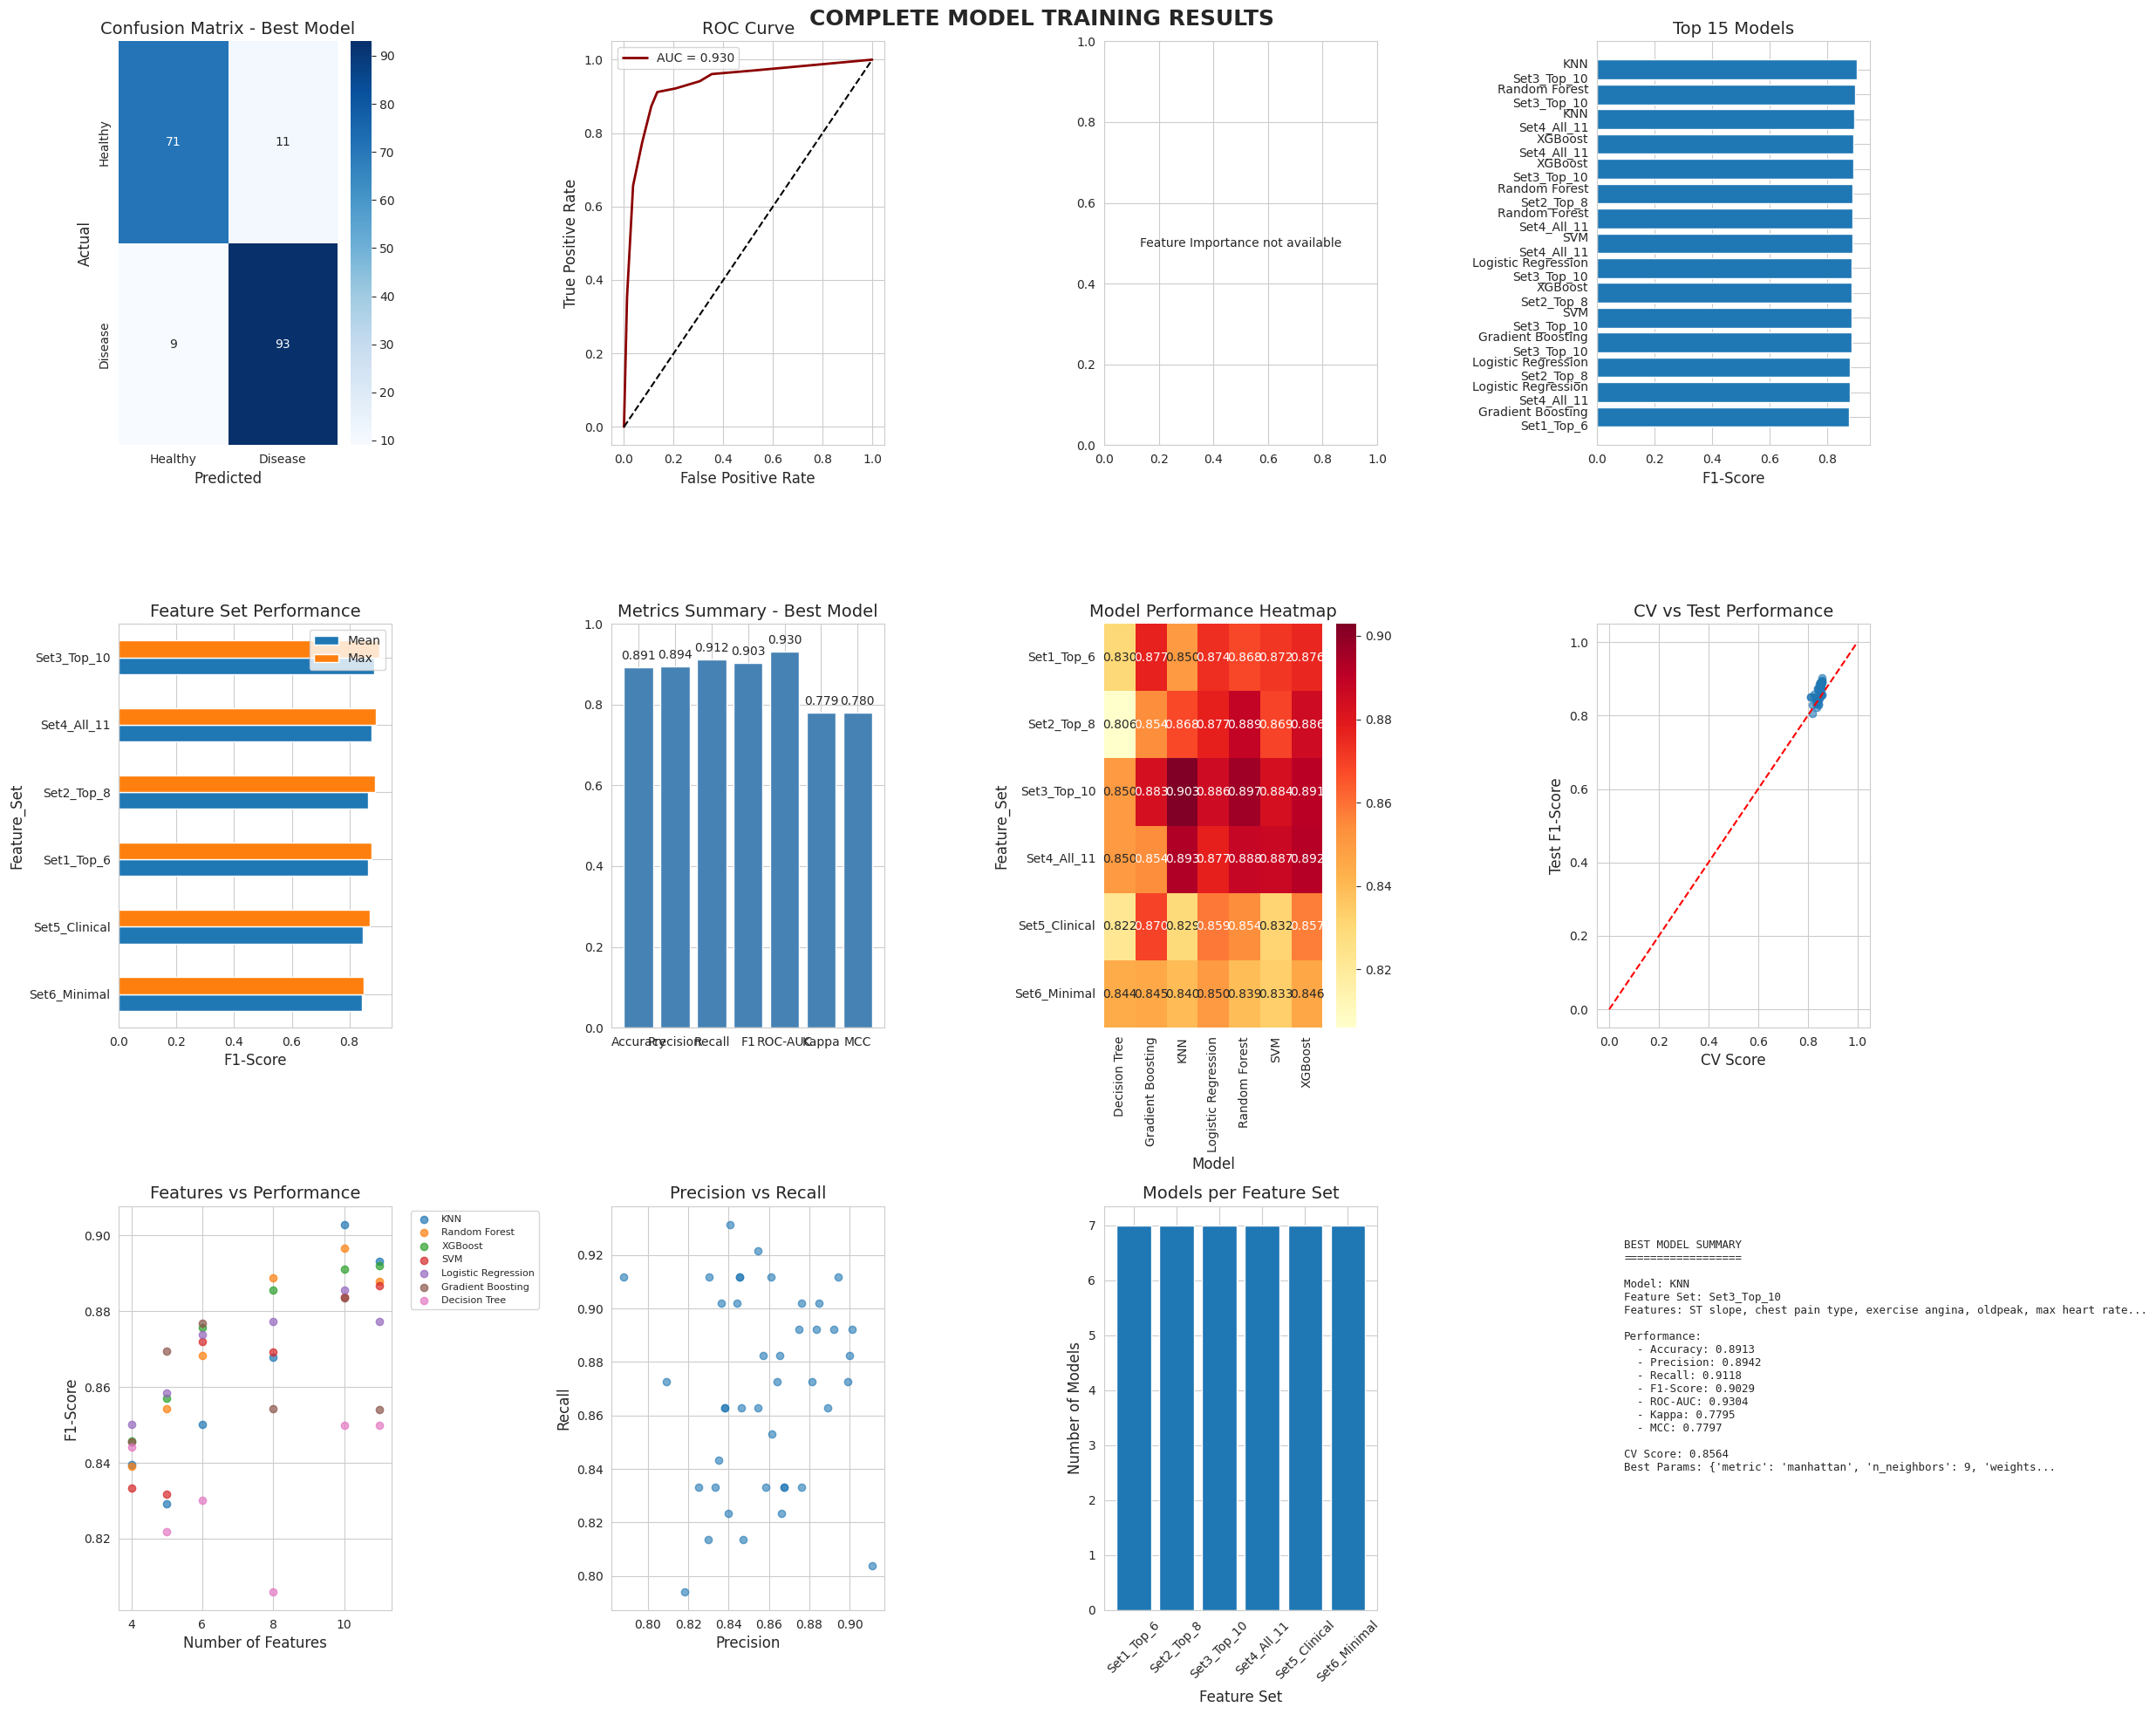

Saved: model_training_results.png

[9] SAVING RESULTS
----------------------------------------
Saved: model_training_results.csv
Saved: best_model_per_feature_set.csv
Saved: feature_sets_used.txt

TRAINING COMPLETE

MODEL TRAINING SUMMARY

FEATURE SETS USED (6 Sets):
  1. Set1_Top_6: 6 features
  2. Set2_Top_8: 8 features
  3. Set3_Top_10: 10 features
  4. Set4_All_11: 11 features
  5. Set5_Clinical: 5 features
  6. Set6_Minimal: 4 features

ALGORITHMS USED (7 Algorithms):
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - SVM
  - KNN
  - Decision Tree

TOTAL EXPERIMENTS: 6 x 7 = 42 models

BEST OVERALL MODEL:
  - Model: KNN
  - Feature Set: Set3_Top_10
  - F1-Score: 0.9029
  - Accuracy: 0.8913
  - ROC-AUC: 0.9304

BEST MODEL PER FEATURE SET:
  - Set1_Top_6: Gradient Boosting (F1=0.8768)
  - Set2_Top_8: Random Forest (F1=0.8889)
  - Set3_Top_10: KNN (F1=0.9029)
  - Set4_All_11: KNN (F1=0.8932)
  - Set5_Clinical: Gradient Boosting (F1=0.8696)
  - Set6_Minima

In [ ]:
# ================================================
# COMPLETE MODEL TRAINING WITH GRID SEARCH
# 6 Feature Sets, Multiple Algorithms, Full Evaluation
# SAVES BEST MODEL PER FEATURE SET
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, cohen_kappa_score, matthews_corrcoef, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("COMPLETE MODEL TRAINING WITH GRID SEARCH")
print("6 Feature Sets, Multiple Algorithms, Full Evaluation")
print("="*80)

# ================================================
# 1. LOAD DATA
# ================================================
print("\n[1] LOADING DATA")
print("-"*40)

df = pd.read_csv('/content/heart_disease_cleaned.csv')
print("Shape: {} rows, {} columns".format(df.shape[0], df.shape[1]))

# ================================================
# 2. DEFINE FEATURE SETS
# ================================================
print("\n[2] DEFINING 6 FEATURE SETS")
print("-"*40)

all_features = ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
                'fasting blood sugar', 'resting ecg', 'max heart rate',
                'exercise angina', 'oldpeak', 'ST slope']

set1 = ['ST slope', 'chest pain type', 'exercise angina', 'oldpeak', 'max heart rate', 'sex']
set2 = ['ST slope', 'chest pain type', 'exercise angina', 'oldpeak',
        'max heart rate', 'sex', 'fasting blood sugar', 'cholesterol']
set3 = ['ST slope', 'chest pain type', 'exercise angina', 'oldpeak',
        'max heart rate', 'sex', 'fasting blood sugar', 'cholesterol',
        'age', 'resting bp s']
set4 = all_features
set5 = ['chest pain type', 'resting bp s', 'max heart rate', 'oldpeak', 'ST slope']
set6 = ['ST slope', 'exercise angina', 'chest pain type', 'oldpeak']

feature_sets = {
    'Set1_Top_6': set1,
    'Set2_Top_8': set2,
    'Set3_Top_10': set3,
    'Set4_All_11': set4,
    'Set5_Clinical': set5,
    'Set6_Minimal': set6
}

print("Feature Sets Defined:")
for name, features in feature_sets.items():
    print("  {}: {} features".format(name, len(features)))

# ================================================
# 3. PREPARE DATA
# ================================================
print("\n[3] PREPARING DATA")
print("-"*40)

X_full = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_features)

# ================================================
# 4. DEFINE MODELS WITH HYPERPARAMETER GRIDS
# ================================================
print("\n[4] DEFINING MODELS AND HYPERPARAMETER GRIDS")
print("-"*40)

models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
        'params': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2],
                   'max_depth': [3, 5, 7], 'subsample': [0.8, 1.0]}
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'],
                   'metric': ['euclidean', 'manhattan']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [5, 10, None], 'min_samples_split': [2, 5, 10],
                   'criterion': ['gini', 'entropy']}
    }
}

print("Models defined: {}".format(list(models.keys())))

# ================================================
# 5. TRAIN MODELS WITH GRID SEARCH
# ================================================
print("\n[5] TRAINING MODELS WITH GRID SEARCH")
print("-"*40)

results = []
best_models = {}

for set_name, features in feature_sets.items():
    print("\nTraining on {} ({} features)".format(set_name, len(features)))

    X_set = X_scaled_df[features].values
    X_train, X_test, y_train, y_test = train_test_split(
        X_set, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, model_config in models.items():
        print("  Running {}...".format(model_name))

        try:
            grid = GridSearchCV(
                model_config['model'],
                model_config['params'],
                cv=5,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=0
            )
            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            best_params = grid.best_params_
            cv_score = grid.best_score_

            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            kappa = cohen_kappa_score(y_test, y_pred)
            mcc = matthews_corrcoef(y_test, y_pred)

            if y_proba is not None:
                roc_auc = roc_auc_score(y_test, y_proba)
            else:
                roc_auc = 0

            results.append({
                'Feature_Set': set_name,
                'n_features': len(features),
                'Model': model_name,
                'Best_Params': str(best_params),
                'CV_Score': cv_score,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'Kappa': kappa,
                'MCC': mcc,
                'ROC_AUC': roc_auc
            })

            key = "{}_{}".format(set_name, model_name)
            best_models[key] = {
                'model': best_model,
                'features': features,
                'feature_names': features,
                'scaler': scaler
            }

        except Exception as e:
            print("    Error: {}".format(str(e)[:50]))

# ================================================
# 6. RESULTS SUMMARY
# ================================================
print("\n[6] RESULTS SUMMARY")
print("-"*40)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1_Score', ascending=False)

print("\nTop 15 Best Models:")
print(results_df[['Model', 'Feature_Set', 'F1_Score', 'Accuracy', 'ROC_AUC', 'CV_Score']].head(15).to_string(index=False))

best_per_set = results_df.loc[results_df.groupby('Feature_Set')['F1_Score'].idxmax()]
print("\nBest Model per Feature Set:")
print(best_per_set[['Feature_Set', 'Model', 'F1_Score', 'Accuracy', 'ROC_AUC']].to_string(index=False))

best_overall = results_df.loc[results_df['F1_Score'].idxmax()]
print("\nOverall Best Model:")
print("  Model: {}".format(best_overall['Model']))
print("  Feature Set: {}".format(best_overall['Feature_Set']))
print("  F1-Score: {:.4f}".format(best_overall['F1_Score']))
print("  Accuracy: {:.4f}".format(best_overall['Accuracy']))
print("  ROC-AUC: {:.4f}".format(best_overall['ROC_AUC']))

# ================================================
# 7. SAVE BEST MODEL PER FEATURE SET
# ================================================
print("\n[7] SAVING BEST MODEL PER FEATURE SET")
print("-"*40)

# Create directory for models
import os
os.makedirs('/content/best_models', exist_ok=True)

# Save best model for each feature set
for _, row in best_per_set.iterrows():
    set_name = row['Feature_Set']
    model_name = row['Model']
    key = "{}_{}".format(set_name, model_name)

    if key in best_models:
        model_info = best_models[key]

        # Save model
        model_path = '/content/best_models/{}_{}.pkl'.format(set_name, model_name)
        joblib.dump(model_info['model'], model_path)

        # Save scaler
        scaler_path = '/content/best_models/{}_{}_scaler.pkl'.format(set_name, model_name)
        joblib.dump(model_info['scaler'], scaler_path)

        # Save features list
        features_path = '/content/best_models/{}_{}_features.txt'.format(set_name, model_name)
        with open(features_path, 'w') as f:
            f.write("FEATURES FOR {} - {}\n".format(set_name, model_name))
            f.write("="*50 + "\n\n")
            for i, feat in enumerate(model_info['features'], 1):
                f.write("{}. {}\n".format(i, feat))

        print("Saved: {}_{}".format(set_name, model_name))

# Save overall best model separately
joblib.dump(best_models[best_key]['model'], '/content/best_model.pkl')
joblib.dump(scaler, '/content/scaler.pkl')
print("\nSaved overall best model: best_model.pkl")

# ================================================
# 8. VISUALIZATIONS
# ================================================
print("\n[8] GENERATING VISUALIZATIONS")
print("-"*40)

best_key = "{}_{}".format(best_overall['Feature_Set'], best_overall['Model'])
best_info = best_models[best_key]
best_model = best_info['model']
best_features = best_info['feature_names']

X_best = X_scaled_df[best_features].values
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(24, 20))

# 1. Confusion Matrix
ax1 = fig.add_subplot(3, 4, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'])
ax1.set_title('Confusion Matrix - Best Model')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. ROC Curve
ax2 = fig.add_subplot(3, 4, 2)
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, linewidth=2, color='darkred', label='AUC = {:.3f}'.format(roc_auc))
    ax2.plot([0, 1], [0, 1], 'k--')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve')
    ax2.legend()

# 3. Feature Importance
ax3 = fig.add_subplot(3, 4, 3)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    ax3.barh(range(len(best_features)), importances[indices])
    ax3.set_yticks(range(len(best_features)))
    ax3.set_yticklabels([best_features[i] for i in indices])
    ax3.set_xlabel('Importance')
    ax3.set_title('Feature Importance')
    ax3.invert_yaxis()
else:
    ax3.text(0.5, 0.5, 'Feature Importance not available', ha='center', va='center')

# 4. Model Comparison - Top 15
ax4 = fig.add_subplot(3, 4, 4)
top15 = results_df.head(15)
ax4.barh(range(len(top15)), top15['F1_Score'])
ax4.set_yticks(range(len(top15)))
ax4.set_yticklabels(["{}\n{}".format(row['Model'], row['Feature_Set'][:15]) for _, row in top15.iterrows()])
ax4.set_xlabel('F1-Score')
ax4.set_title('Top 15 Models')
ax4.invert_yaxis()

# 5. Feature Set Comparison
ax5 = fig.add_subplot(3, 4, 5)
set_perf = results_df.groupby('Feature_Set')['F1_Score'].agg(['mean', 'max']).sort_values('mean')
set_perf.plot(kind='barh', ax=ax5)
ax5.set_xlabel('F1-Score')
ax5.set_title('Feature Set Performance')
ax5.legend(['Mean', 'Max'])

# 6. Metrics Summary - Best Model
ax6 = fig.add_subplot(3, 4, 6)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Kappa', 'MCC']
values = [best_overall['Accuracy'], best_overall['Precision'],
          best_overall['Recall'], best_overall['F1_Score'],
          best_overall['ROC_AUC'], best_overall['Kappa'], best_overall['MCC']]
ax6.bar(metrics, values, color='steelblue')
ax6.set_ylim(0, 1)
ax6.set_title('Metrics Summary - Best Model')
for i, v in enumerate(values):
    ax6.text(i, v + 0.02, '{:.3f}'.format(v), ha='center')

# 7. Model Performance by Feature Set (Heatmap)
ax7 = fig.add_subplot(3, 4, 7)
pivot = results_df.pivot_table(index='Feature_Set', columns='Model', values='F1_Score')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax7)
ax7.set_title('Model Performance Heatmap')

# 8. CV vs Test Score
ax8 = fig.add_subplot(3, 4, 8)
ax8.scatter(results_df['CV_Score'], results_df['F1_Score'], alpha=0.6)
ax8.plot([0, 1], [0, 1], 'r--')
ax8.set_xlabel('CV Score')
ax8.set_ylabel('Test F1-Score')
ax8.set_title('CV vs Test Performance')

# 9. Feature Set Size vs Performance
ax9 = fig.add_subplot(3, 4, 9)
for model in results_df['Model'].unique():
    subset = results_df[results_df['Model'] == model]
    ax9.scatter(subset['n_features'], subset['F1_Score'], label=model, alpha=0.7)
ax9.set_xlabel('Number of Features')
ax9.set_ylabel('F1-Score')
ax9.set_title('Features vs Performance')
ax9.legend(bbox_to_anchor=(1.05, 1), fontsize=8)

# 10. Precision-Recall Distribution
ax10 = fig.add_subplot(3, 4, 10)
ax10.scatter(results_df['Precision'], results_df['Recall'], alpha=0.6)
ax10.set_xlabel('Precision')
ax10.set_ylabel('Recall')
ax10.set_title('Precision vs Recall')
ax10.grid(True)

# 11. Model Count by Feature Set
ax11 = fig.add_subplot(3, 4, 11)
feature_counts = results_df.groupby('Feature_Set').size()
ax11.bar(feature_counts.index, feature_counts.values)
ax11.set_xlabel('Feature Set')
ax11.set_ylabel('Number of Models')
ax11.set_title('Models per Feature Set')
ax11.tick_params(axis='x', rotation=45)

# 12. Best Model Summary Text
ax12 = fig.add_subplot(3, 4, 12)
ax12.axis('off')
summary_text = """
BEST MODEL SUMMARY
==================

Model: {}
Feature Set: {}
Features: {}

Performance:
  - Accuracy: {:.4f}
  - Precision: {:.4f}
  - Recall: {:.4f}
  - F1-Score: {:.4f}
  - ROC-AUC: {:.4f}
  - Kappa: {:.4f}
  - MCC: {:.4f}

CV Score: {:.4f}
Best Params: {}
""".format(
    best_overall['Model'],
    best_overall['Feature_Set'],
    ', '.join(best_features[:5]) + ('...' if len(best_features) > 5 else ''),
    best_overall['Accuracy'],
    best_overall['Precision'],
    best_overall['Recall'],
    best_overall['F1_Score'],
    best_overall['ROC_AUC'],
    best_overall['Kappa'],
    best_overall['MCC'],
    best_overall['CV_Score'],
    best_overall['Best_Params'][:50] + '...' if len(str(best_overall['Best_Params'])) > 50 else str(best_overall['Best_Params'])
)
ax12.text(0.1, 0.95, summary_text, transform=ax12.transAxes, fontsize=9,
          verticalalignment='top', fontfamily='monospace')

plt.suptitle('COMPLETE MODEL TRAINING RESULTS', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/model_training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_training_results.png")

# ================================================
# 9. SAVE RESULTS
# ================================================
print("\n[9] SAVING RESULTS")
print("-"*40)

results_df.to_csv('/content/model_training_results.csv', index=False)
print("Saved: model_training_results.csv")

best_per_set.to_csv('/content/best_model_per_feature_set.csv', index=False)
print("Saved: best_model_per_feature_set.csv")

# Save feature sets used
with open('/content/feature_sets_used.txt', 'w') as f:
    f.write("FEATURE SETS USED IN TRAINING\n")
    f.write("="*50 + "\n\n")
    for name, features in feature_sets.items():
        f.write("{} ({} features):\n".format(name, len(features)))
        for i, feat in enumerate(features, 1):
            f.write("  {}. {}\n".format(i, feat))
        f.write("\n")
print("Saved: feature_sets_used.txt")

# ================================================
# 10. FINAL SUMMARY
# ================================================
print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)

summary = """
MODEL TRAINING SUMMARY
======================

FEATURE SETS USED (6 Sets):
  1. Set1_Top_6: 6 features
  2. Set2_Top_8: 8 features
  3. Set3_Top_10: 10 features
  4. Set4_All_11: 11 features
  5. Set5_Clinical: 5 features
  6. Set6_Minimal: 4 features

ALGORITHMS USED (7 Algorithms):
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - SVM
  - KNN
  - Decision Tree

TOTAL EXPERIMENTS: 6 x 7 = 42 models

BEST OVERALL MODEL:
  - Model: {}
  - Feature Set: {}
  - F1-Score: {:.4f}
  - Accuracy: {:.4f}
  - ROC-AUC: {:.4f}

BEST MODEL PER FEATURE SET:
""".format(
    best_overall['Model'],
    best_overall['Feature_Set'],
    best_overall['F1_Score'],
    best_overall['Accuracy'],
    best_overall['ROC_AUC']
)

for _, row in best_per_set.iterrows():
    summary += "  - {}: {} (F1={:.4f})\n".format(row['Feature_Set'], row['Model'], row['F1_Score'])

summary += """
SAVED BEST MODELS:
"""
for _, row in best_per_set.iterrows():
    summary += "  - /content/best_models/{}_{}.pkl\n".format(row['Feature_Set'], row['Model'])
    summary += "    /content/best_models/{}_{}_scaler.pkl\n".format(row['Feature_Set'], row['Model'])

summary += """
OUTPUT FILES:
  1. model_training_results.csv - Complete results (42 models)
  2. best_model_per_feature_set.csv - Best model per set
  3. model_training_results.png - Visualizations
  4. best_model.pkl - Best overall model
  5. scaler.pkl - Fitted scaler
  6. feature_sets_used.txt - Feature sets list
  7. best_models/ - Directory with best model per feature set

================================================================================
MODEL READY FOR DEPLOYMENT
================================================================================
"""

print(summary)

with open('/content/training_summary.txt', 'w') as f:
    f.write(summary)

print("\nComplete! All files saved in /content/ directory")